# Analyzing 30-Day Readmissions in Diabetes Patients

### Rachael Ray Hobbs
#### 5/18/2026

## Exploratory Data Analysis
This notebook explores the diabetes hospital readmission dataset to understand its structure, data quality, patient characteristics, hospital utilization patterns, medication information, and 30-day readmission outcome.

In [52]:
import pandas as pd
pd.options.display.max_columns = 50

import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Introduction

This project uses the Diabetes 130-US Hospitals dataset from the UCI Machine Learning Repository, which contains 101,766 inpatient hospital encounters from 130 U.S. hospitals and integrated delivery networks between 1999 and 2008. Each record represents a patient encounter involving a diabetes diagnosis, lab testing, medication administration, and a hospital stay of 1 to 14 days. The dataset includes demographic, clinical, hospital utilization, diagnosis, medication, and readmission-related variables.

The goal of this project is to explore factors associated with hospital readmission among patients with diabetes, with particular attention to whether a patient was readmitted within 30 days of discharge. Because the data includes sensitive demographic variables such as age, gender, and race, this analysis should be interpreted carefully and used as an educational data science project rather than as a clinical decision-making tool.

Dataset citation: Clore, J., Cios, K., DeShazo, J., & Strack, B. (2014). Diabetes 130-US Hospitals for Years 1999-2008 [Dataset](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008). UCI Machine Learning Repository.

## Dataset Overview

Reviews the dataset shape, column types, and general structure before cleaning.

In [53]:
dirty_df = pd.read_csv(
    "../data/diabetic_data.csv",
    na_values="?",
    low_memory=False
)

In [54]:
dirty_df.shape

(101766, 50)

In [55]:
dirty_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

### Column Overview

The dataset includes patient, hospital, clinical, medication, and readmission information.

- **Identifiers:** `encounter_id`, `patient_nbr`
- **Demographics:** `race`, `gender`, `age`, `weight`
- **Hospital visit details:** admission type/source, discharge status, and `time_in_hospital`
- **Clinical measures:** lab procedures, procedures, medications, prior visits, and diagnosis count
- **Diagnosis codes:** `diag_1`, `diag_2`, `diag_3`
- **Lab results:** `max_glu_serum`, `A1Cresult`
- **Diabetes medications:** medication-specific columns such as `metformin`, `insulin`, and others
- **Treatment indicators:** `change`, `diabetesMed`
- **Target variable:** `readmitted`, showing whether a patient was readmitted as `NO`, `>30`, or `<30`

In [56]:
dirty_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Data Cleaning and Feature Preparation

Maps coded hospital ID columns to descriptive labels, removes identifier columns, handles missing values, and prepares the dataset for EDA.

In [57]:
dirty_df["patient_nbr"].nunique()

71518

In [58]:
cols_without_encounter = dirty_df.columns.drop("encounter_id")

dirty_df.duplicated(subset=cols_without_encounter).sum()

0

### Missing Values

Evaluates missing data and documents the removal or imputation strategy used before analysis.

In [59]:
na_perc = dirty_df.isna().mean() * 100

remove_col = na_perc[na_perc > 35].index.tolist() + ["encounter_id", "patient_nbr"]

dropped_col_table = (
    na_perc.reindex(remove_col)
    .fillna(0)
    .round(2)
    .reset_index()
)

dropped_col_table.columns = ["column", "percent_missing"]

diabetic_df = dirty_df.drop(
    columns=remove_col,
    errors="ignore"
).copy()

dropped_col_table

,column,percent_missing
0,weight,96.86
1,payer_code,39.56
2,medical_specialty,49.08
3,max_glu_serum,94.75
4,A1Cresult,83.28
5,encounter_id,0.00
6,patient_nbr,0.00


In [60]:
na_col = na_perc[(na_perc > 0) & (na_perc < 35)]

na_col

race      2.233555
diag_1    0.020636
diag_2    0.351787
diag_3    1.398306
dtype: float64

In [61]:
cols_to_impute = ["race", "diag_1", "diag_2", "diag_3"]

diabetic_df[cols_to_impute] = diabetic_df[cols_to_impute].fillna("Unknown")

Columns with more than **35% missing values** were removed from the dataset, including `weight`, `payer_code`, `medical_specialty`, `max_glu_serum`, and `A1Cresult`.

Patient identifier columns, `encounter_id` and `patient_nbr`, were also dropped because they do not provide meaningful predictive information.

For columns with less than **3% missing values**, missing entries were imputed as `"Unknown"`. This included `race`, `diag_1`, `diag_2`, and `diag_3`.

In [62]:
diabetic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  number_outpatient         101766 non-null  int64 
 11  number_emergency          101766 non-null  int64 
 12  number_inpatient          101766 non-null  int64 
 13  diag_1                    101766 non-null  object
 14  diag

### ID Code Mapping

The columns `admission_type_id`, `discharge_disposition_id`, and `admission_source_id` use numeric ID codes. These codes were mapped to more descriptive category labels to make the dataset easier to interpret during analysis and visualization.

In [63]:
clean_df = diabetic_df.copy()

id_cols = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

mapping_file = "../data/IDS_mapping.xlsx"

for col in id_cols:
    mapping_df = pd.read_excel(mapping_file, sheet_name=col)

    # Make both sides the same type
    mapping_df[col] = mapping_df[col].astype(str).str.strip()
    clean_df[col] = clean_df[col].astype(str).str.strip()

    mapper = dict(zip(mapping_df[col], mapping_df["description"]))

    clean_df[col] = clean_df[col].map(mapper)

In [64]:
clean_df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,Not Mapped,Physician Referral,1,41,0,1,0,0,0,250.83,Unknown,Unknown,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),Emergency,Discharged to home,Emergency Room,3,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),Emergency,Discharged to home,Emergency Room,2,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),Emergency,Discharged to home,Emergency Room,2,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),Emergency,Discharged to home,Emergency Room,1,51,0,8,0,0,0,197,157,250,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Target Variable: 30-Day Readmission

Creates a binary target variable indicating whether each patient was readmitted within 30 days of discharge.

In [65]:
clean_df["readmitted_30"] = np.where(
    clean_df["readmitted"] == "<30",
    "YES",
    "NO"
)

## Univariate Analysis

Examines the distribution of individual variables, including the target variable, demographics, hospital utilization measures, medications, and prior visits.

#### Target Distribution

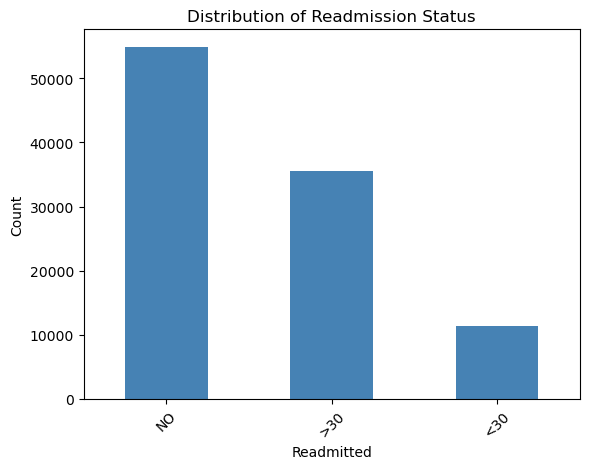

In [66]:
clean_df["readmitted"].value_counts().plot(kind="bar", color = "steelblue")

plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.title("Distribution of Readmission Status")
plt.xticks(rotation=45)
plt.show()

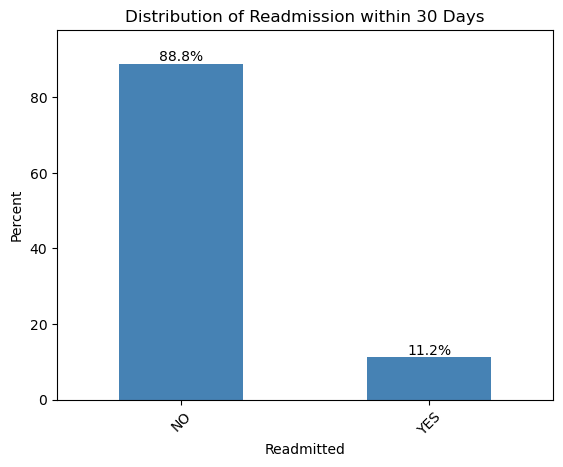

In [67]:
readmitt_pct = clean_df["readmitted_30"].value_counts(normalize=True) * 100

ax = readmitt_pct.plot(kind="bar", color = "steelblue")

plt.xlabel("Readmitted")
plt.ylabel("Percent")
plt.title("Distribution of Readmission within 30 Days")
plt.xticks(rotation=45)

for i, pct in enumerate(readmitt_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, readmitt_pct.max() * 1.1)
plt.show()

#### Patient Demographics

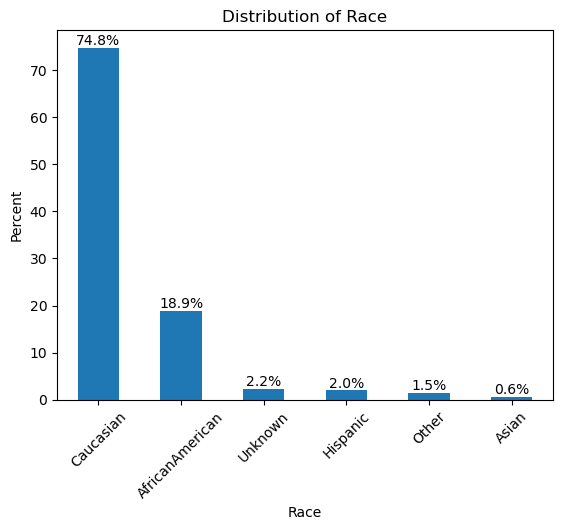

In [68]:
race_pct = clean_df["race"].value_counts(normalize=True) * 100

ax = race_pct.plot(kind="bar")

plt.xlabel("Race")
plt.ylabel("Percent")
plt.title("Distribution of Race")
plt.xticks(rotation=45)

for i, pct in enumerate(race_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

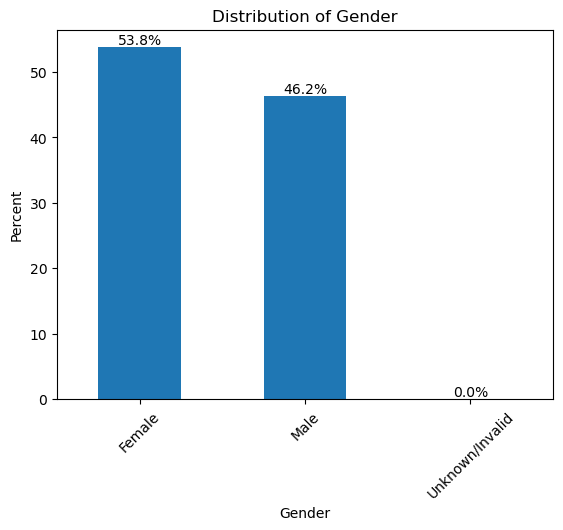

In [69]:
gender_pct = clean_df["gender"].value_counts(normalize=True)*100

ax = gender_pct.plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Percent")
plt.title("Distribution of Gender")
plt.xticks(rotation=45)

for i, pct in enumerate(gender_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )
plt.show()

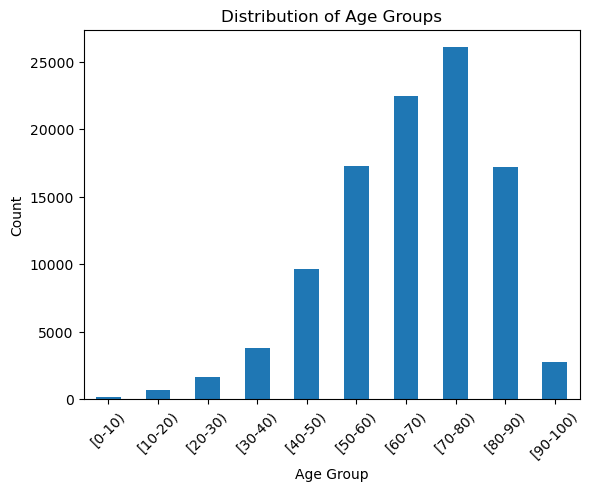

In [70]:
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

clean_df["age"].value_counts().reindex(age_order).plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Count")
plt.title("Distribution of Age Groups")
plt.xticks(rotation=45)
plt.show()

In [71]:
age_map = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

clean_df["age"] = clean_df["age"].map(age_map)

#### Hospital Encounter Features

In [72]:
admiss_pct = (
    clean_df["admission_type_id"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

admiss_pct.columns = ["admission_type_id", "percent"]

admiss_pct

,admission_type_id,percent
0,Emergency,55.96
1,Elective,19.56
2,Urgent,19.16
3,Not Available,4.96
4,Not Mapped,0.33
5,Trauma Center,0.02
6,Newborn,0.01


In [73]:
clean_df.loc[
    clean_df["admission_type_id"].isin(["Not Mapped", "Trauma Center", "Newborn"]),
    "admission_type_id"
] = "Not Available"

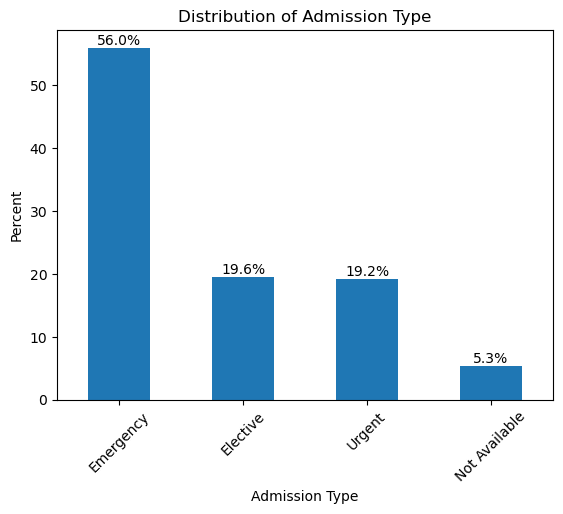

In [74]:
admiss_pct = clean_df["admission_type_id"].value_counts(normalize=True)*100

ax = admiss_pct.plot(kind="bar")

plt.xlabel("Admission Type")
plt.ylabel("Percent")
plt.title("Distribution of Admission Type")
plt.xticks(rotation=45)

for i, pct in enumerate(admiss_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )
plt.show()

In [75]:
discharge_pct = (
    clean_df["discharge_disposition_id"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

discharge_pct.columns = ["discharge_disposition_id", "percent"]

discharge_pct

,discharge_disposition_id,percent
0,Discharged to home,61.42
1,Discharged/transferred to SNF,14.23
2,Discharged/transferred to home with home healt...,13.16
3,Discharged/transferred to another short term h...,2.17
4,Discharged/transferred to another rehab fac in...,2.03
5,Expired,1.67
6,Discharged/transferred to another type of inpa...,1.21
7,Not Mapped,1.01
8,Discharged/transferred to ICF,0.83
9,Left AMA,0.64


In [76]:
discharge_pct = clean_df["discharge_disposition_id"].value_counts(normalize=True)*100

small_discharge_groups = discharge_pct.loc[
    discharge_pct < 5
].index

clean_df.loc[
    clean_df["discharge_disposition_id"].isin(small_discharge_groups),
    "discharge_disposition_id"
] = "Other"

clean_df.loc[
    clean_df["discharge_disposition_id"].isin(["Discharged/transferred to home with home health service"]),
    "discharge_disposition_id"
] = "Sent home w/ health service"

clean_df.loc[
    clean_df["discharge_disposition_id"].isin(["Discharged/transferred to SNF"]),
    "discharge_disposition_id"
] = "Sent to Skilled Nursing Facility"

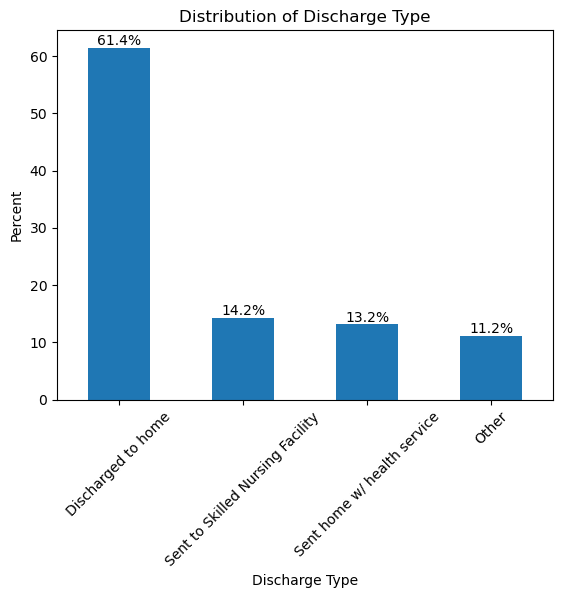

In [77]:
discharge_pct = clean_df["discharge_disposition_id"].value_counts(normalize=True)*100

ax = discharge_pct.plot(kind="bar")

plt.xlabel("Discharge Type")
plt.ylabel("Percent")
plt.title("Distribution of Discharge Type")
plt.xticks(rotation=45)

for i, pct in enumerate(discharge_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )
plt.show()

In [78]:
admin_source_pct = (
    clean_df["admission_source_id"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

admin_source_pct.columns = ["admission_source_id", "percent"]

admin_source_pct

,admission_source_id,percent
0,Emergency Room,60.53
1,Physician Referral,31.13
2,Transfer from a hospital,3.36
3,Transfer from another health care facility,2.38
4,Clinic Referral,1.16
5,Transfer from a Skilled Nursing Facility (SNF),0.90
6,HMO Referral,0.20
7,Not Mapped,0.17
8,Not Available,0.13
9,Court/Law Enforcement,0.02


In [79]:
admission_pct = clean_df["admission_source_id"].value_counts(normalize=True)*100

transfer_hospital = ["Transfer from critial access hospital", "Transfer from Ambulatory Surgery Center"]
transfer_hc = ["Transfer from a Skilled Nursing Facility (SNF)"]

clean_df.loc[
    clean_df["admission_source_id"].isin(transfer_hc),
    "admission_source_id"
] = "Transfer from another health care facility"

clean_df.loc[
    clean_df["admission_source_id"].isin(transfer_hospital),
    "admission_source_id"
] = "Transfer from a hospital"


small_admission_groups = admission_pct.loc[
    admission_pct < 3
].index

clean_df.loc[
    clean_df["admission_source_id"].isin(small_admission_groups),
    "admission_source_id"
] = "Other"

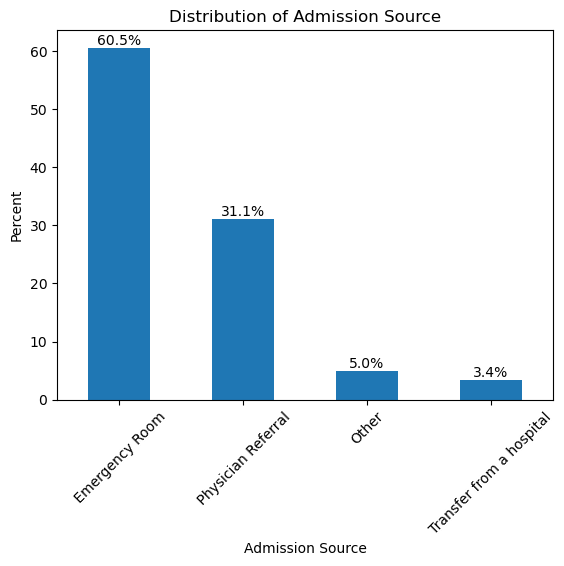

In [80]:
admission_pct = clean_df["admission_source_id"].value_counts(normalize=True)*100

ax = admission_pct.plot(kind="bar")

plt.xlabel("Admission Source")
plt.ylabel("Percent")
plt.title("Distribution of Admission Source")
plt.xticks(rotation=45)

for i, pct in enumerate(admission_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )
plt.show()

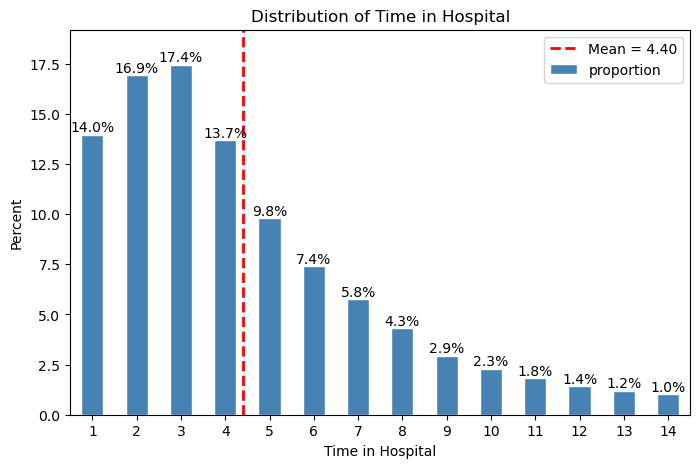

In [81]:
mean_hos = clean_df["time_in_hospital"].mean()

time_pct = (
    clean_df["time_in_hospital"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)


plt.figure(figsize=(8, 5))
ax = time_pct.plot(kind="bar", color="steelblue", edgecolor="white")

plt.axvline(
    mean_hos - 1,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_hos:.2f}"
)

plt.xlabel("Time in Hospital")
plt.ylabel("Percent")
plt.title("Distribution of Time in Hospital")
plt.xticks(rotation=0)

for i, pct in enumerate(time_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, time_pct.max() * 1.1)
plt.legend()
plt.show()

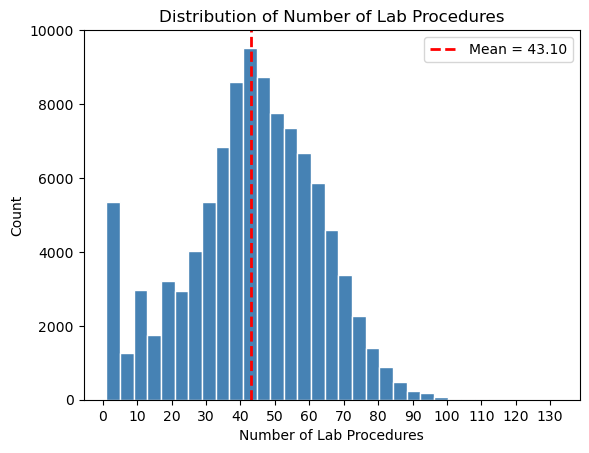

In [82]:
mean_proc = clean_df["num_lab_procedures"].mean()

plt.hist(clean_df["num_lab_procedures"], color="steelblue", edgecolor="white", bins= int(clean_df["num_lab_procedures"].max()/4))

plt.axvline(mean_proc, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_proc:.2f}")

plt.xlabel("Number of Lab Procedures")
plt.ylabel("Count")
plt.title("Distribution of Number of Lab Procedures")
plt.xticks(range(0, 131, 10))
plt.legend()
plt.show()

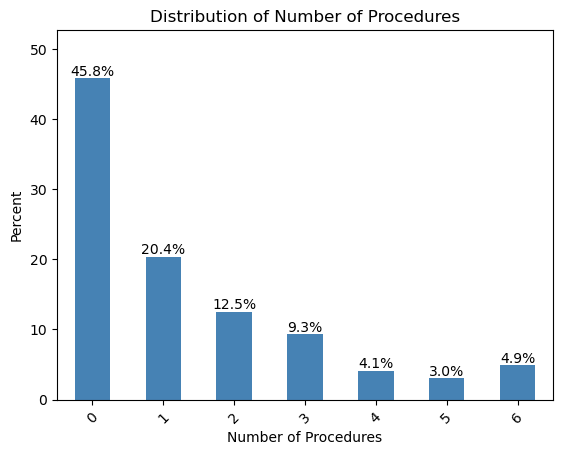

In [83]:
proc_pct = (
    clean_df["num_procedures"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

ax = proc_pct.plot(kind="bar", color = "steelblue")

plt.xlabel("Number of Procedures")
plt.ylabel("Percent")
plt.title("Distribution of Number of Procedures")
plt.xticks(rotation=45)

for i, pct in enumerate(proc_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, proc_pct.max() * 1.15)
plt.show()

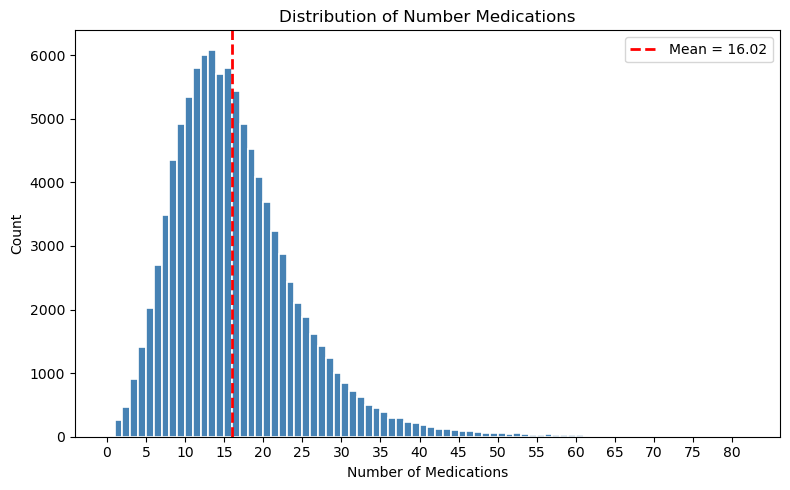

In [84]:
mean_meds = clean_df["num_medications"].mean()

plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["num_medications"],
    bins= range(0, clean_df["num_medications"].max() + 2),
    color="steelblue",
    edgecolor="white",
    linewidth=1.2
)

plt.axvline(
    mean_meds,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_meds:.2f}"
)

plt.xlabel("Number of Medications")
plt.ylabel("Count")
plt.title("Distribution of Number Medications")
plt.xticks(range(0, clean_df["num_medications"].max() + 1, 5))
plt.legend()
plt.tight_layout()
plt.show()

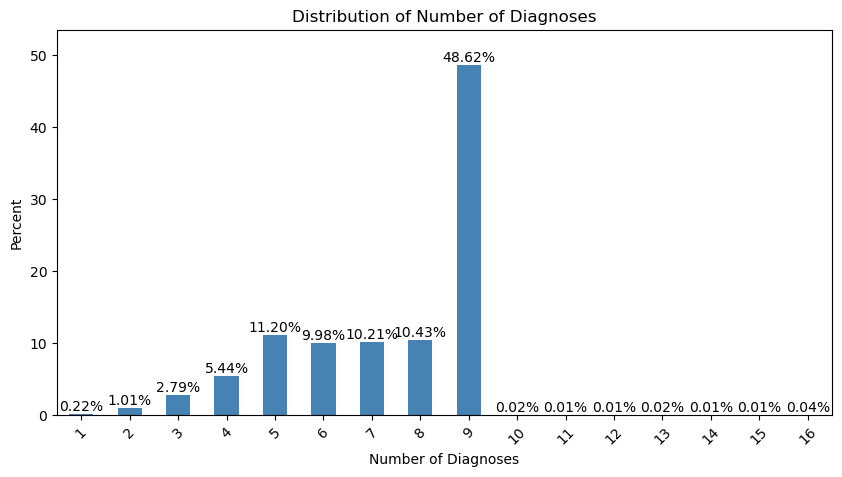

In [85]:
diag_pct = (
    clean_df["number_diagnoses"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

plt.figure(figsize=(10, 5))
ax = diag_pct.plot(kind="bar", color = "steelblue")

plt.xlabel("Number of Diagnoses")
plt.ylabel("Percent")
plt.title("Distribution of Number of Diagnoses")
plt.xticks(rotation=45)

for i, pct in enumerate(diag_pct):
    ax.text(
        i,
        pct,
        f"{pct:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, diag_pct.max() * 1.1)
plt.show()

In [86]:
less_3 = [1,2,3]
more_9 = range(9,17)

clean_df.loc[
    clean_df["number_diagnoses"].isin(less_3),
    "number_diagnoses"
] = 3

clean_df.loc[
    clean_df["number_diagnoses"].isin(more_9),
    "number_diagnoses"
] = 9

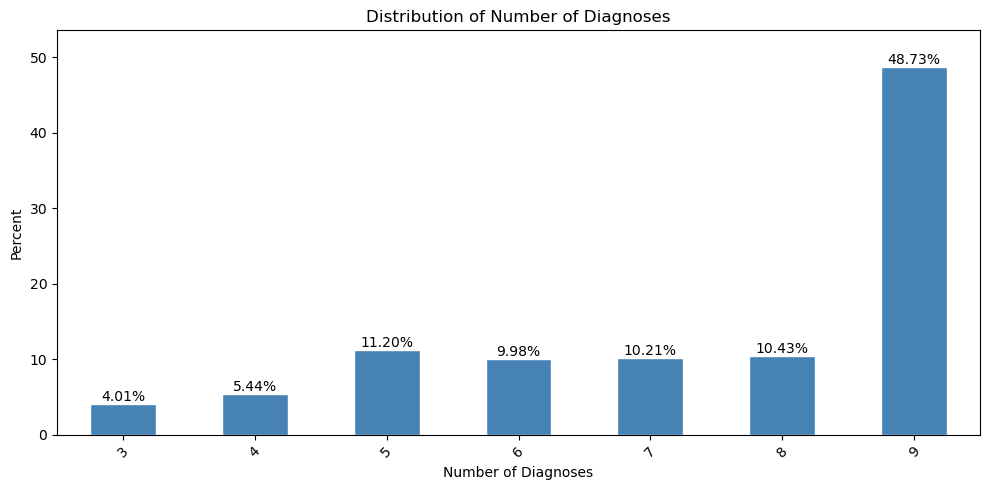

In [89]:
diag_order = [3, 4, 5, 6, 7, 8, 9]

clean_df["number_diagnoses"] = pd.to_numeric(
    clean_df["number_diagnoses"],
    errors="coerce"
)

diag_pct = (
    clean_df["number_diagnoses"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(diag_order, fill_value=0)
)

plt.figure(figsize=(10, 5))
ax = diag_pct.plot(kind="bar", color="steelblue", edgecolor="white")

plt.xlabel("Number of Diagnoses")
plt.ylabel("Percent")
plt.title("Distribution of Number of Diagnoses")
plt.xticks(rotation=45)

for i, pct in enumerate(diag_pct.values):
    ax.text(
        i,
        pct,
        f"{pct:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, diag_pct.max() * 1.1)
plt.tight_layout()
plt.show()

In [90]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 44 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  int64 
 3   admission_type_id         96475 non-null   object
 4   discharge_disposition_id  98075 non-null   object
 5   admission_source_id       94985 non-null   object
 6   time_in_hospital          101766 non-null  int64 
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  number_outpatient         101766 non-null  int64 
 11  number_emergency          101766 non-null  int64 
 12  number_inpatient          101766 non-null  int64 
 13  diag_1                    101766 non-null  object
 14  diag

In [91]:
clean_df.describe()

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,65.967022,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.431657
std,15.940838,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.882951
min,5.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000
25%,55.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,65.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,75.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,95.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,9.000000


#### Prior Utilization Features

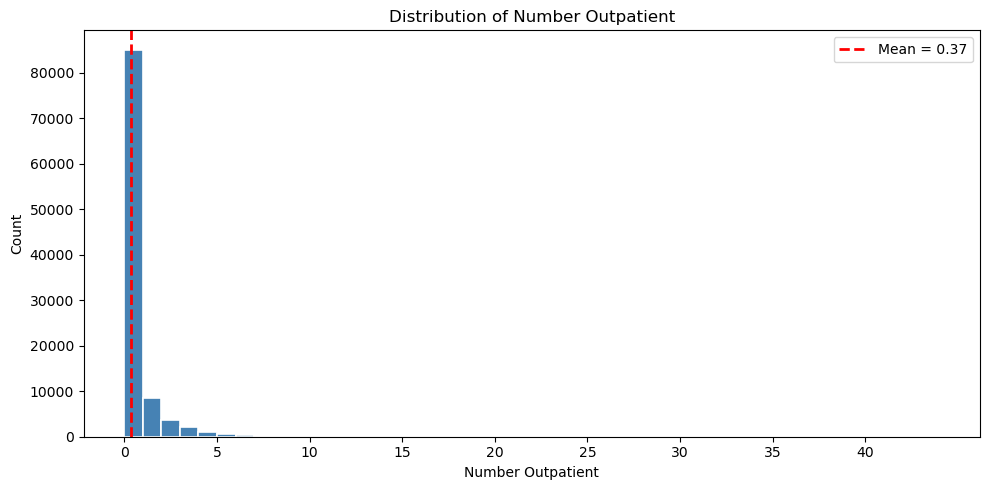

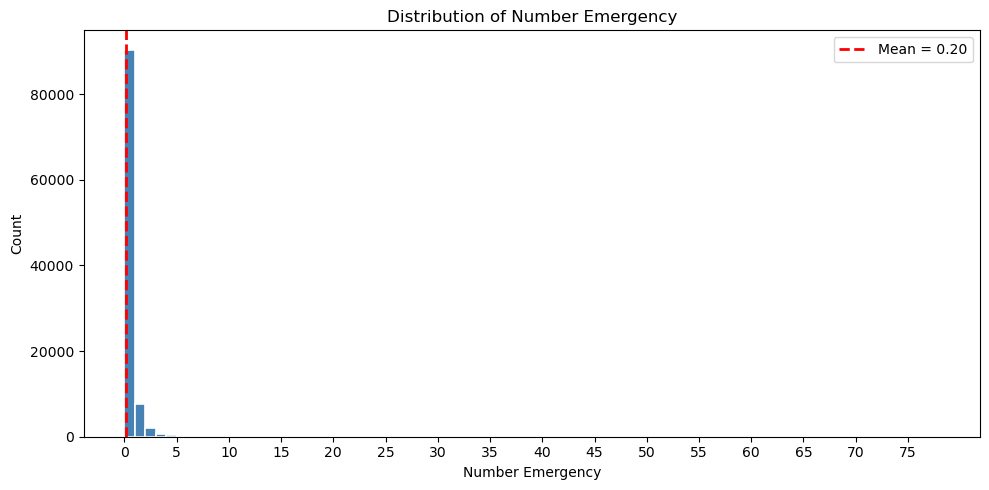

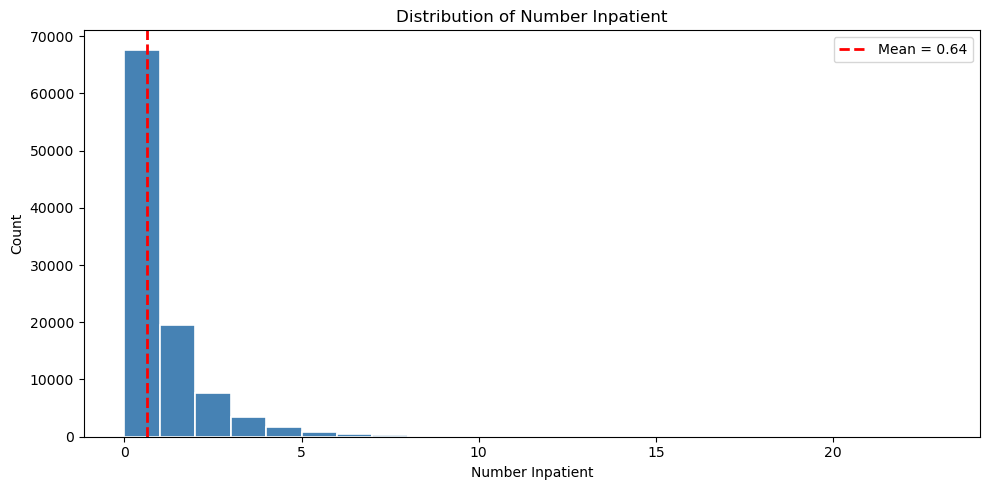

In [92]:
visit_cols = ["number_outpatient", "number_emergency", "number_inpatient"]

for i, col in enumerate(visit_cols):
    mean_out = clean_df[col].mean()

    plt.figure(figsize=(10, 5))

    plt.hist(
        clean_df[col],
        bins=range(0, int(clean_df[col].max()) + 3),
        color="steelblue",
        edgecolor="white",
        linewidth=1.2
    )

    clean_name = col.replace("_", " ").title()

    plt.axvline(
        mean_out,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_out:.2f}"
    )

    plt.xlabel(clean_name)
    plt.ylabel("Count")
    plt.title(f"Distribution of {clean_name}")
    plt.xticks(range(0, int(clean_df[col].max()) + 1, 5))
    plt.legend()
    plt.tight_layout()
    plt.show()

In [93]:
visit_cols = ["number_outpatient", "number_emergency", "number_inpatient"]
more_6 = range(6, max(clean_df["number_emergency"]) + 1)

for col in visit_cols:
    clean_df.loc[
        clean_df[col].isin(more_6),
        col
] = 6

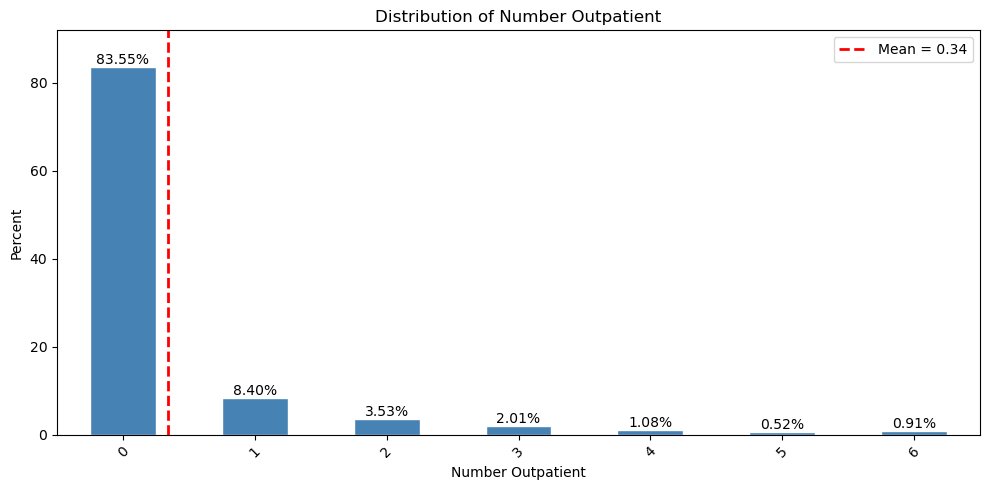

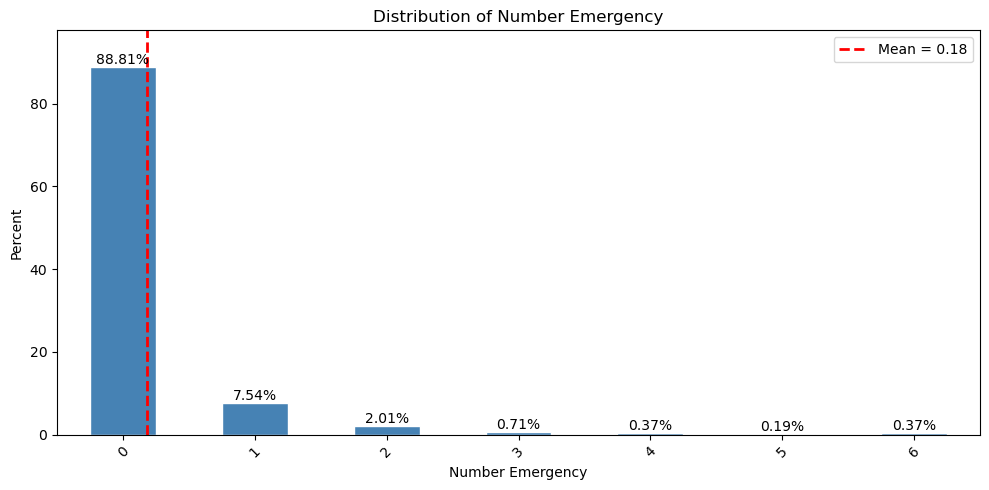

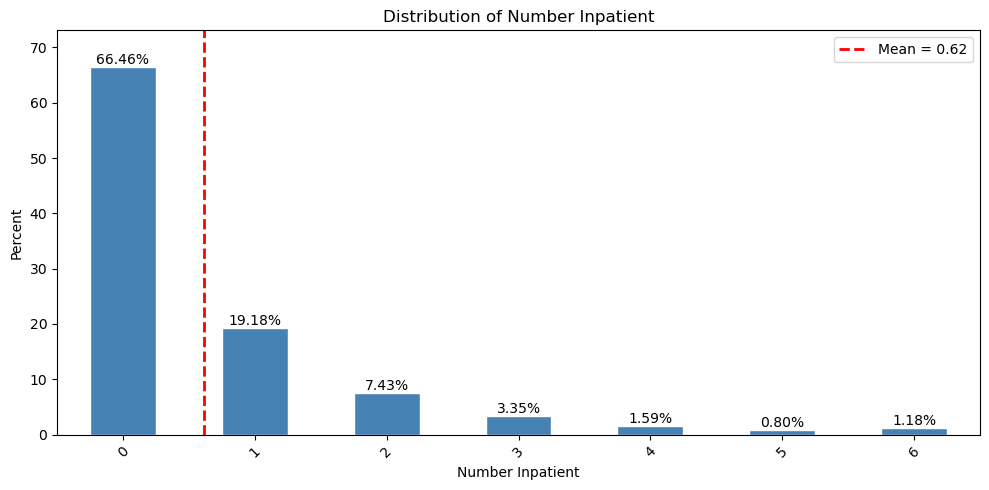

In [94]:
visit_order = [0, 1, 2, 3, 4, 5, 6]

for i, col in enumerate(visit_cols): 
    mean_out = clean_df[col].mean()
    visit_pct = (
        clean_df[col]
        .value_counts(normalize=True, sort=False)
        .reindex(visit_order)
        .mul(100)
    )

    plt.figure(figsize=(10, 5))
    ax = visit_pct.plot(
        kind="bar",
        color="steelblue",
        edgecolor="white"
    )

    plt.axvline(
        mean_out,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_out:.2f}"
    )


    clean_name = col.replace("_", " ").title()

    plt.xlabel(clean_name)
    plt.ylabel("Percent")
    plt.title(f"Distribution of {clean_name}")
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles=[handles[0]], labels=[labels[0]])
    plt.xticks(rotation=45)

    for i, pct in enumerate(visit_pct.values):
        ax.text(
            i,
            pct,
            f"{pct:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.ylim(0, visit_pct.max() * 1.1)

    plt.tight_layout()
    plt.show()

In [95]:
clean_df["number_health_service"] = (
    clean_df["number_outpatient"] 
    + clean_df["number_emergency"] 
    + clean_df["number_inpatient"]
)

#### Medications

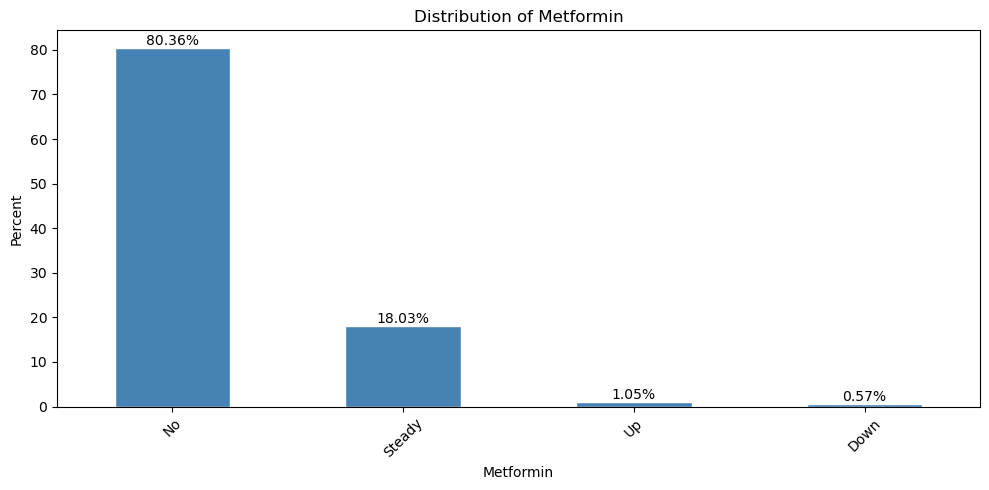

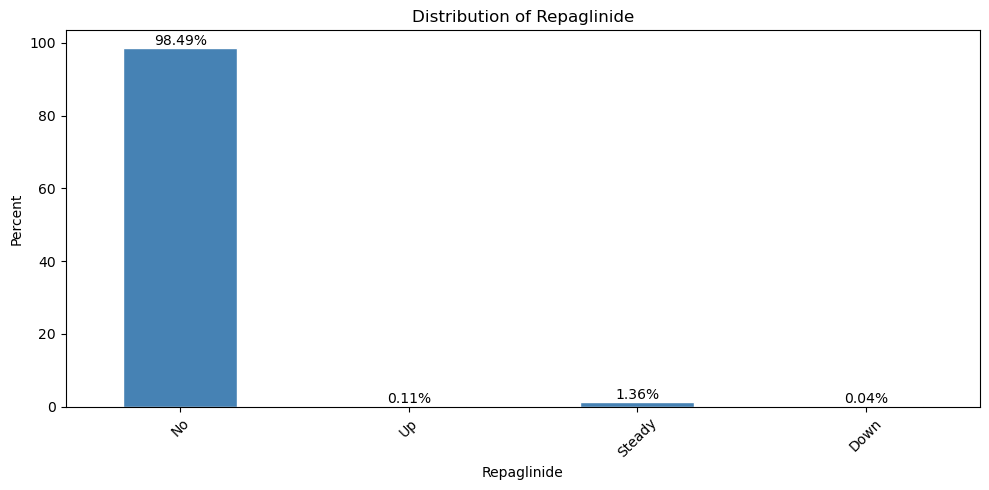

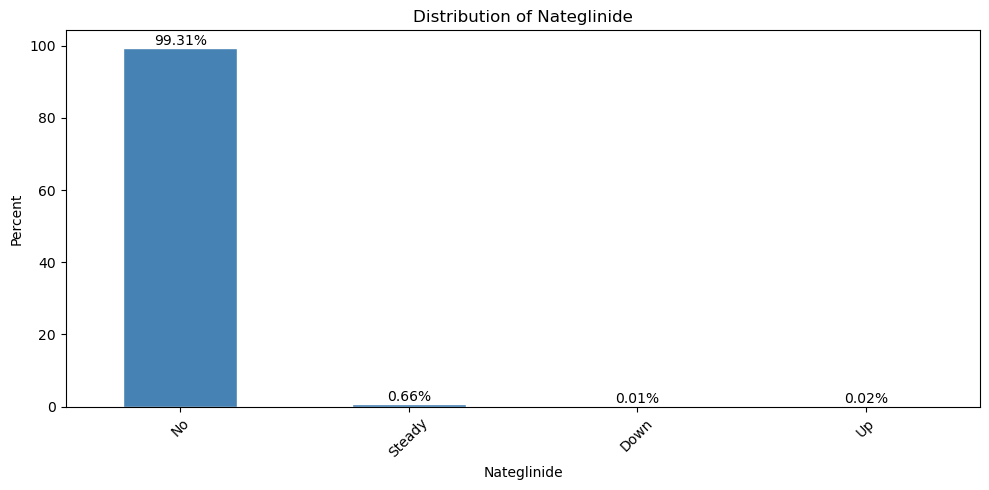

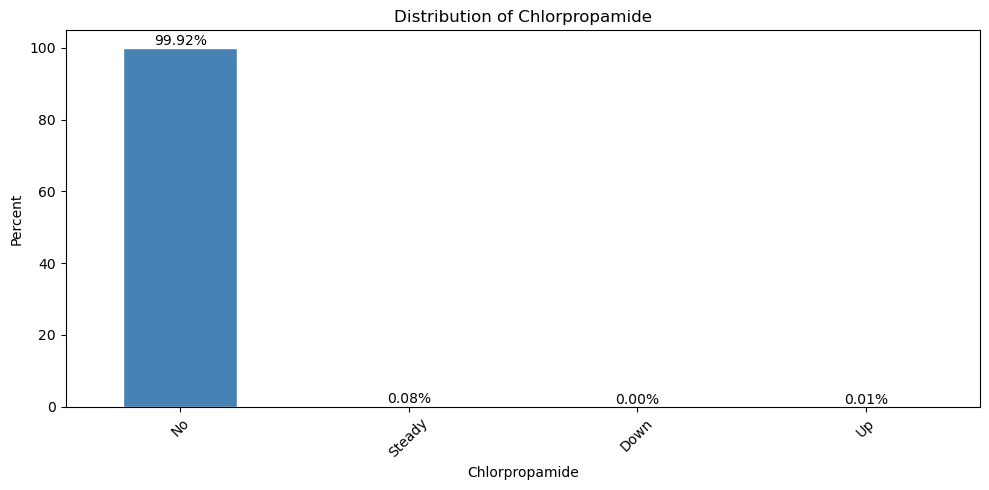

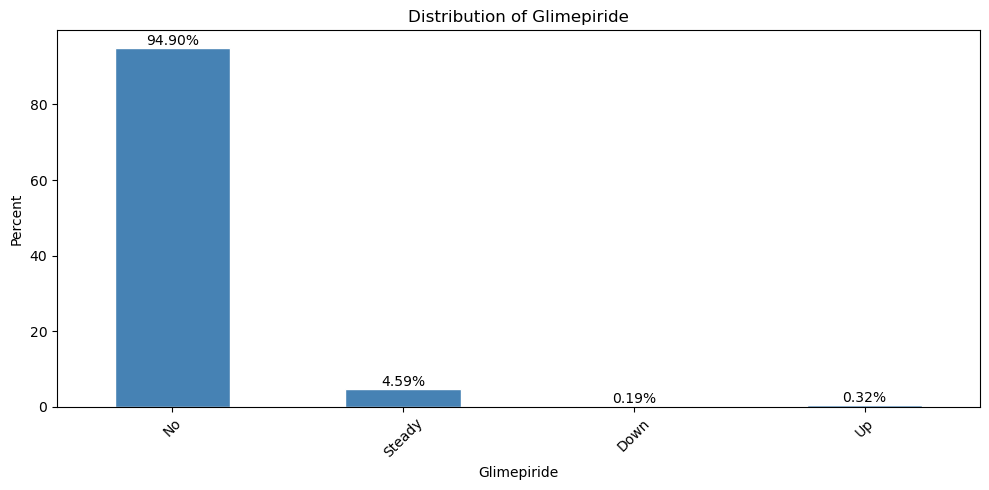

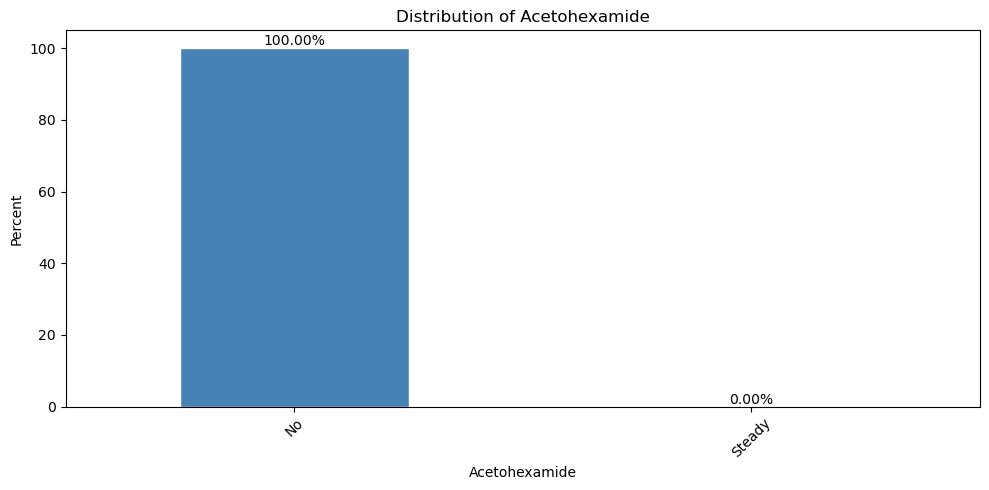

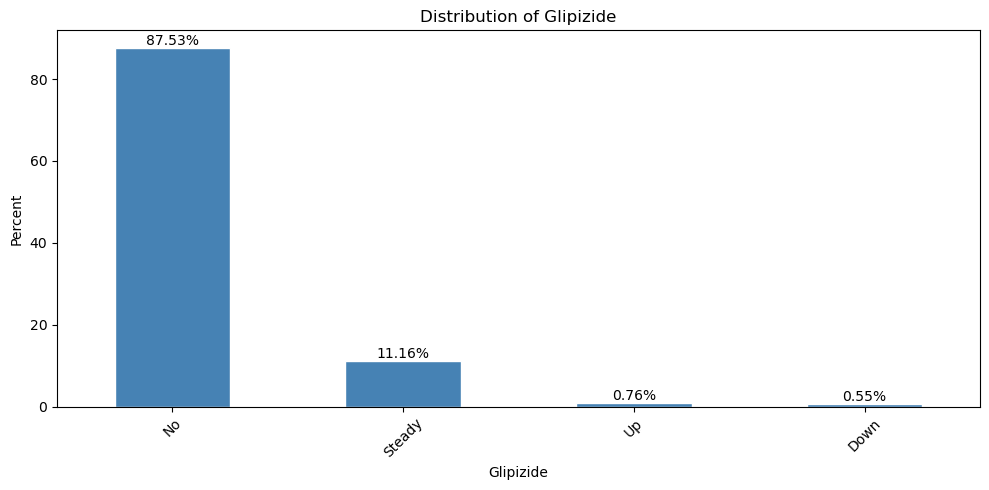

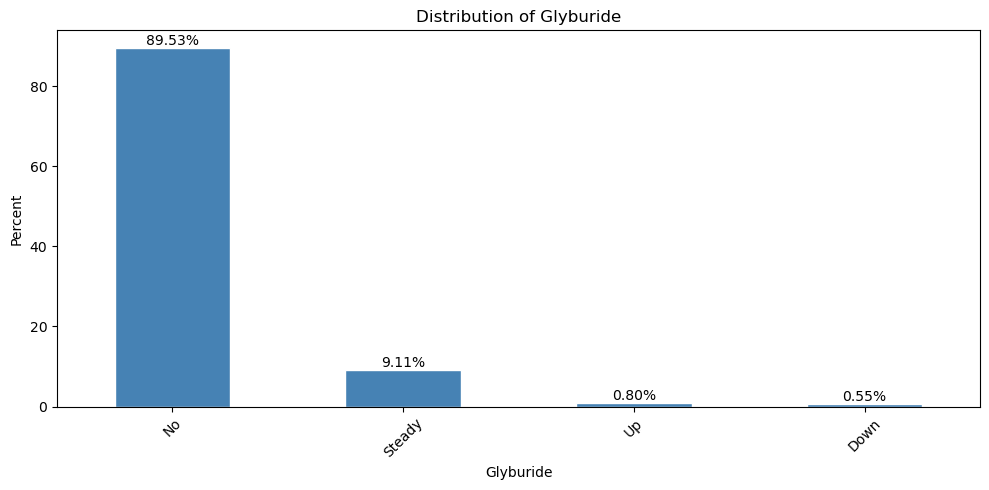

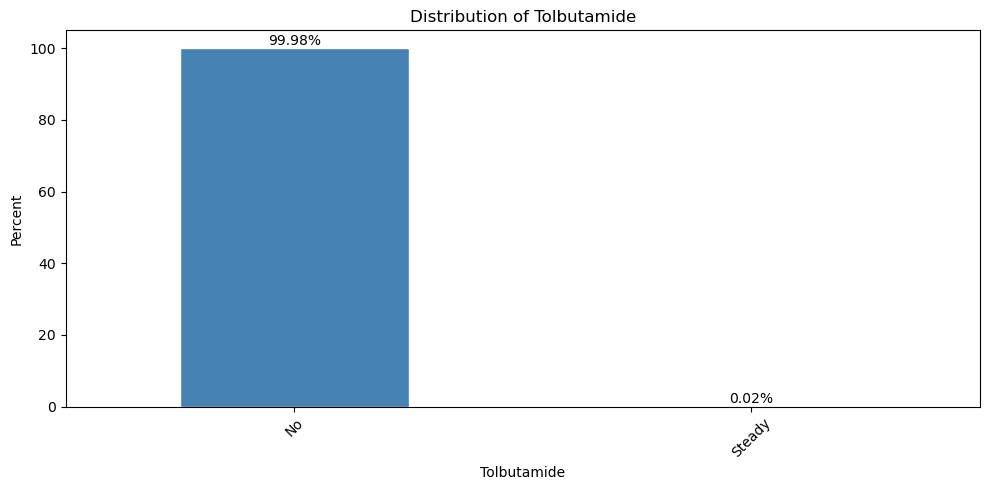

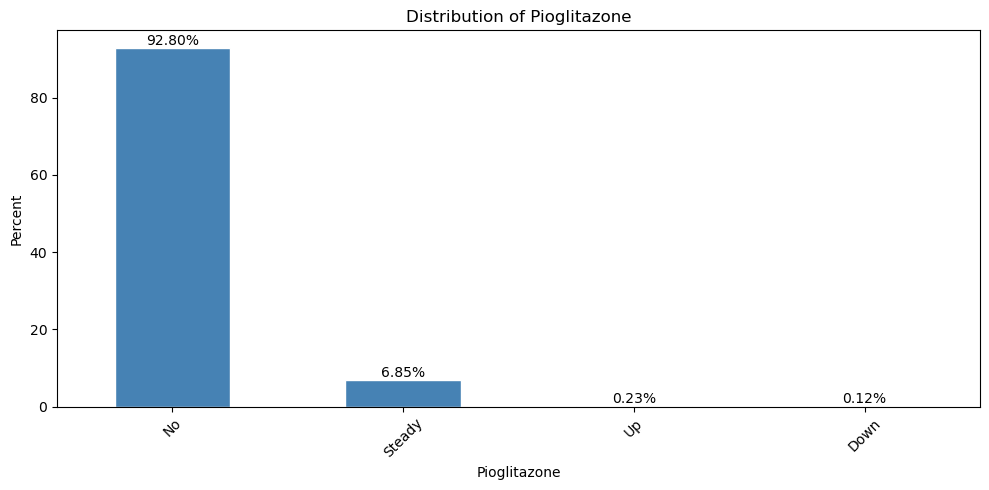

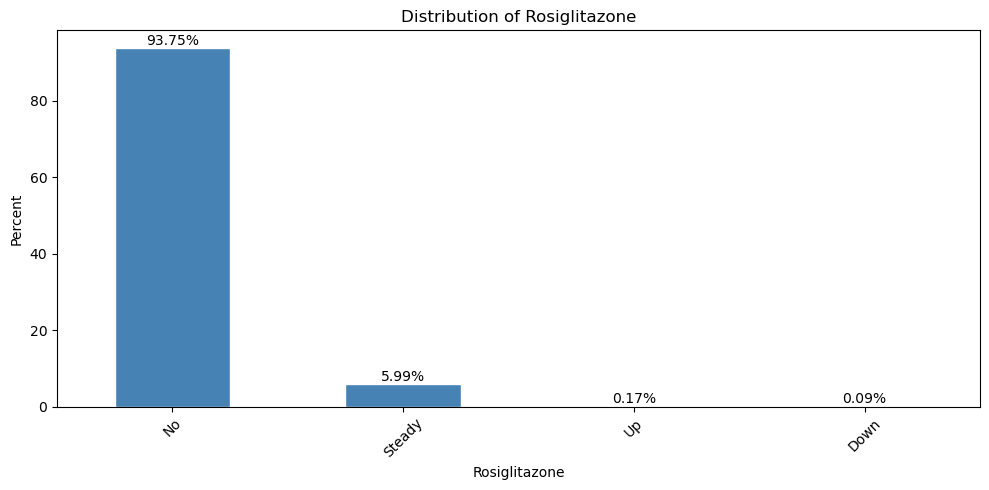

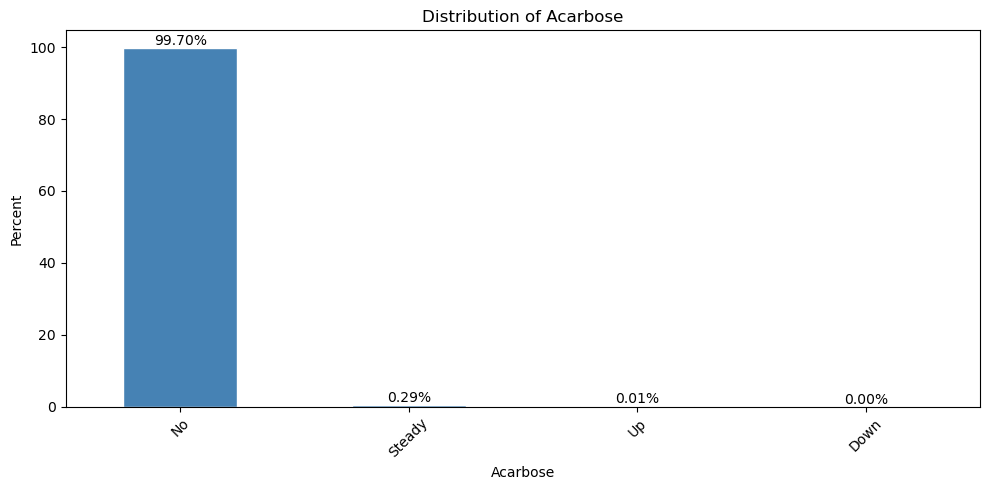

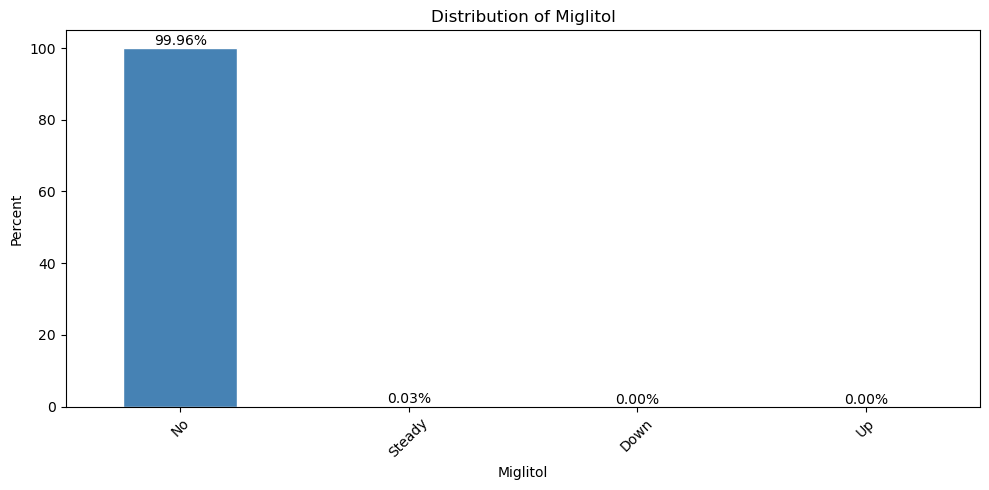

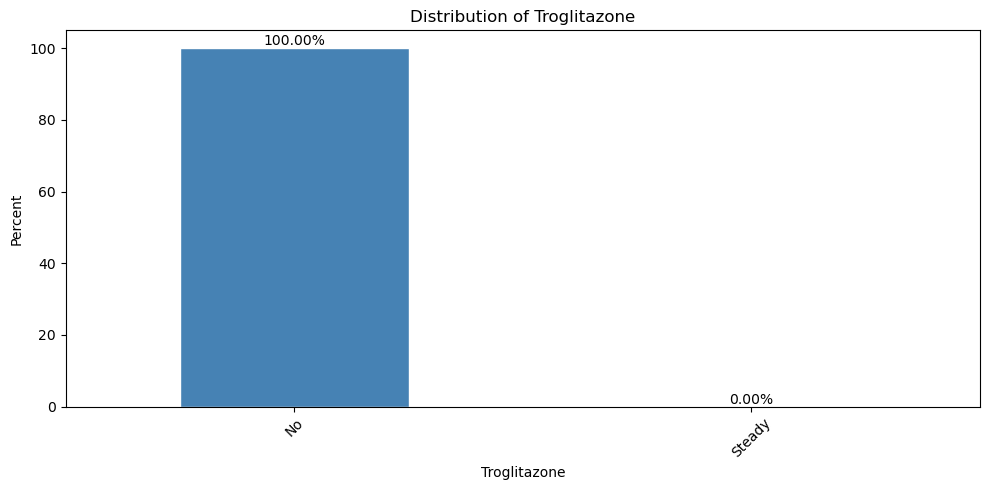

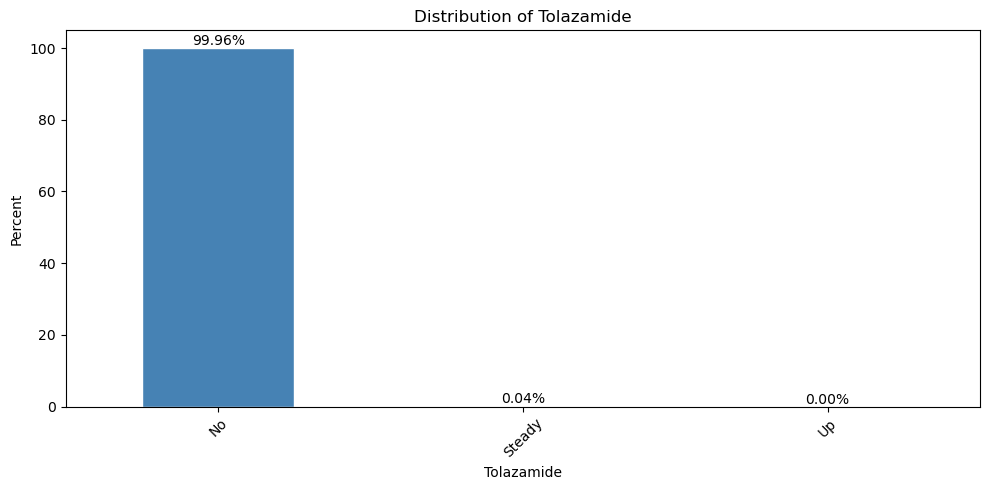

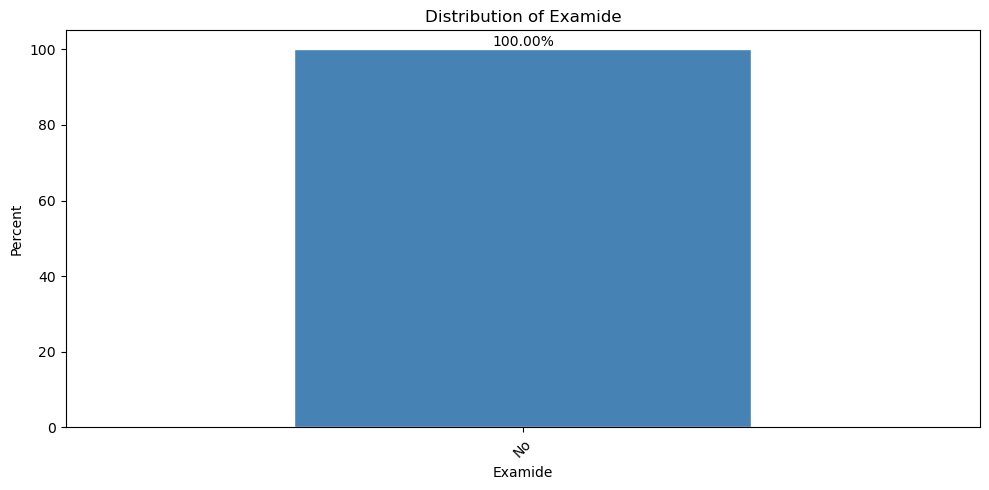

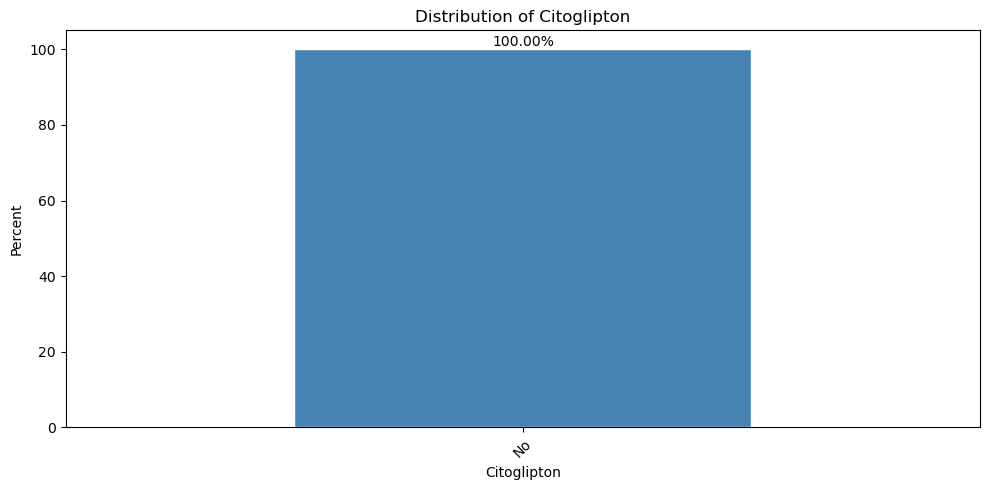

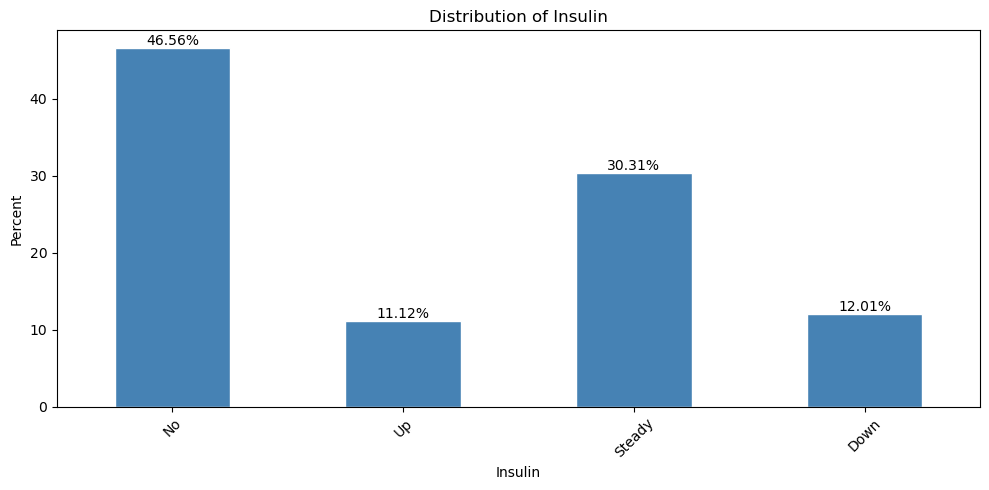

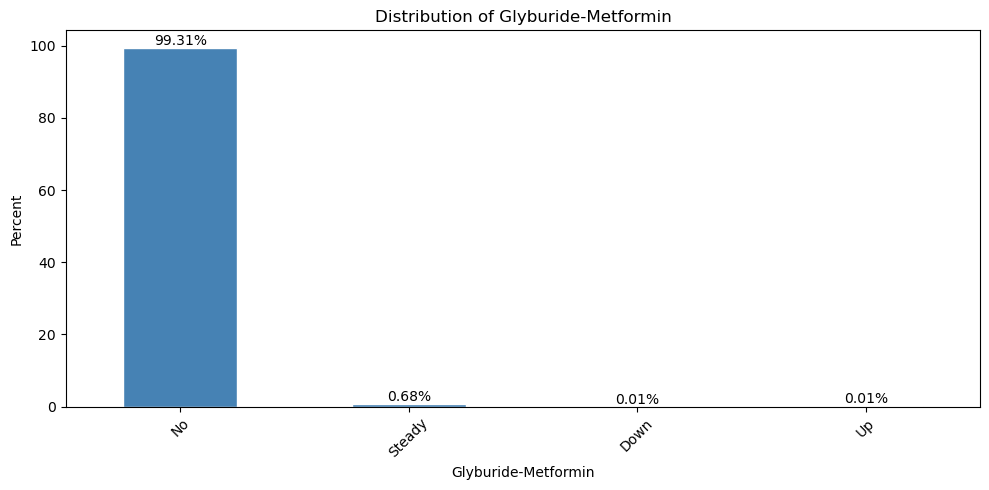

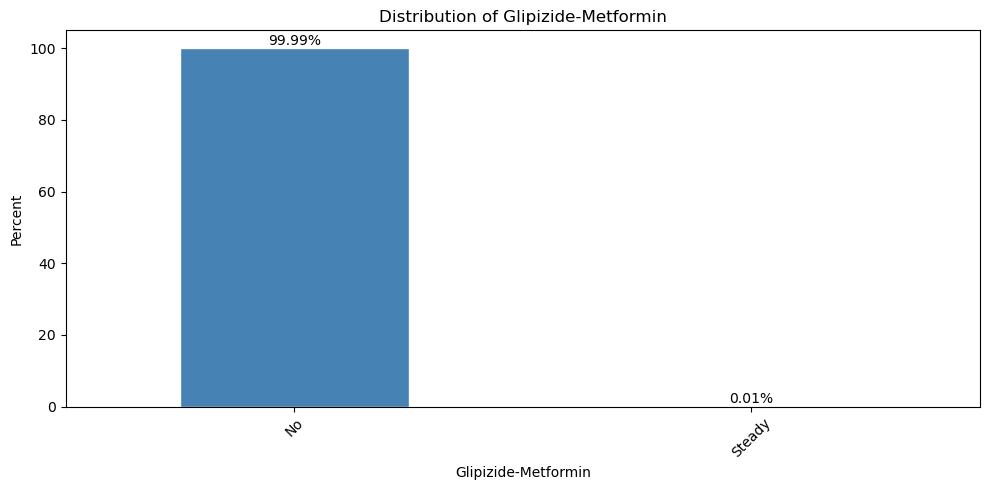

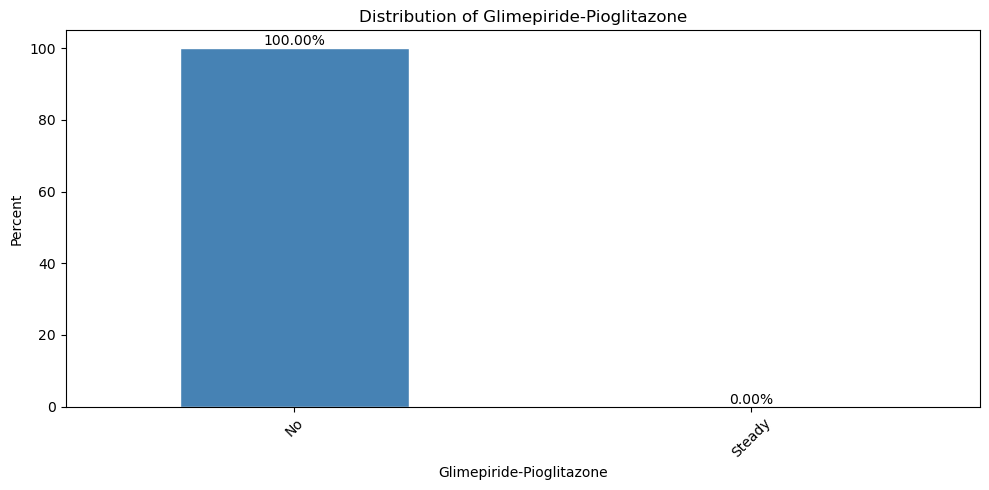

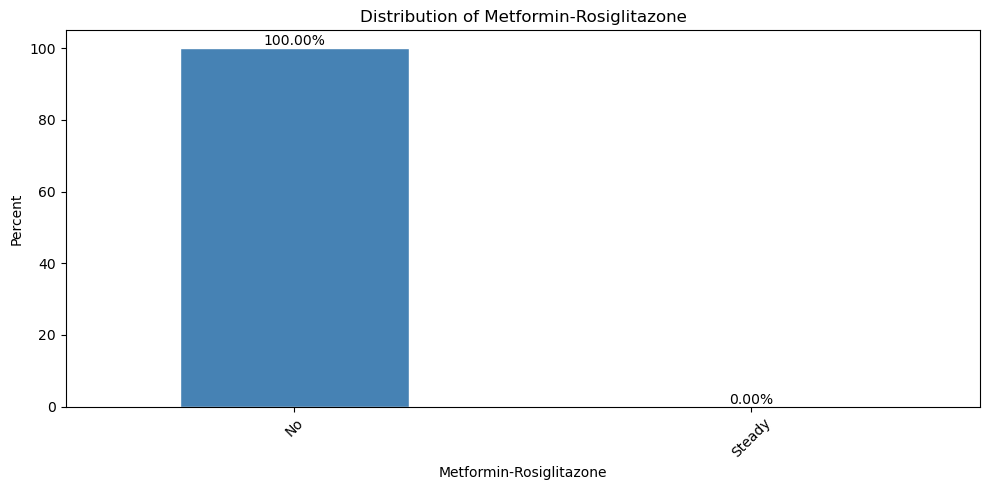

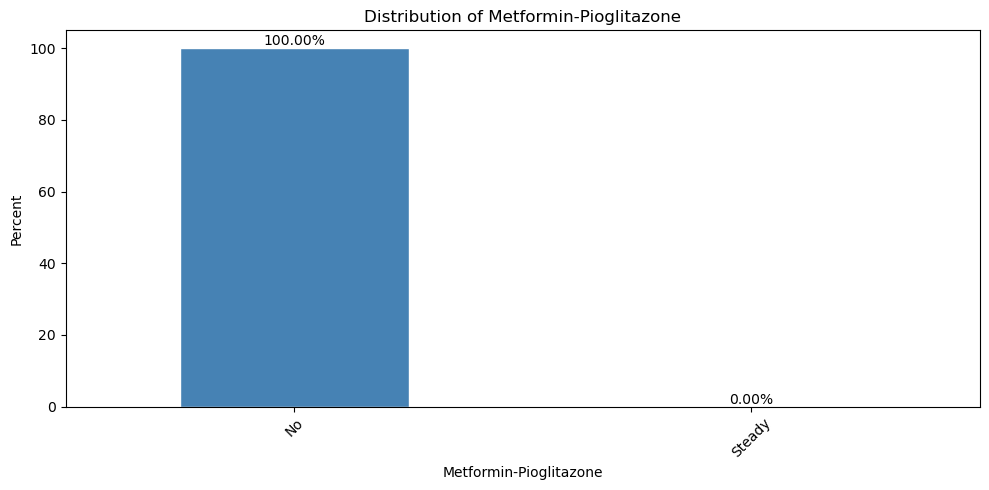

In [96]:
med_cols = clean_df.columns[17:40]


for i, col in enumerate(med_cols): 
    med_pct = (
        clean_df[col]
        .value_counts(normalize=True, sort=False)
        .mul(100)
    )

    plt.figure(figsize=(10, 5))
    ax = med_pct.plot(
        kind="bar",
        color="steelblue",
        edgecolor="white"
    )

    clean_name = col.replace("_", " ").title()

    plt.xlabel(clean_name)
    plt.ylabel("Percent")
    plt.title(f"Distribution of {clean_name}")
    plt.xticks(rotation=45)

    for i, pct in enumerate(med_pct.values):
        ax.text(
            i,
            pct,
            f"{pct:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

In [97]:
keep_meds = [
    "Metformin", "Glimepiride", "Glipizide", "Glyburide", 
    "Pioglitazone", "Rosiglitazone", "Insulin"
]

clean_df["steady_count"] = clean_df[med_cols].eq("Steady").sum(axis=1)
clean_df["up_count"] = clean_df[med_cols].eq("Up").sum(axis=1)
clean_df["down_count"] = clean_df[med_cols].eq("Down").sum(axis=1)
   

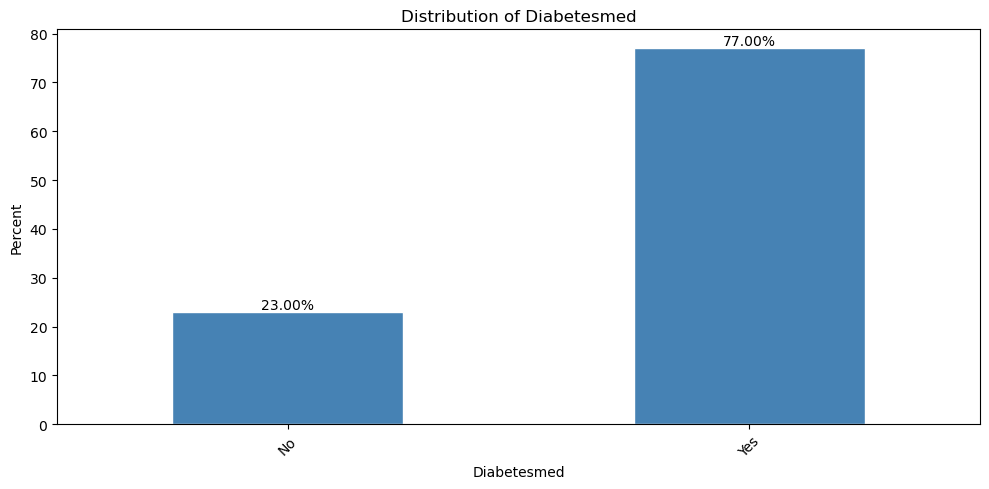

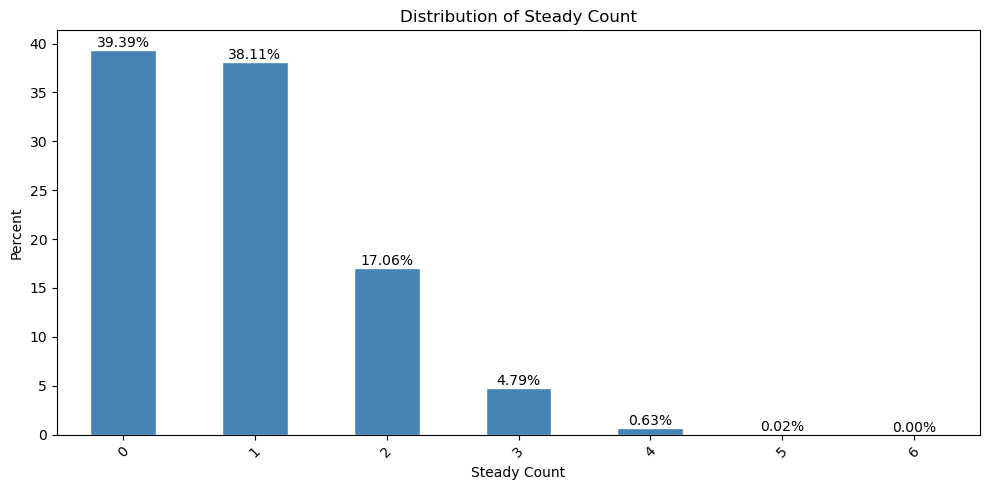

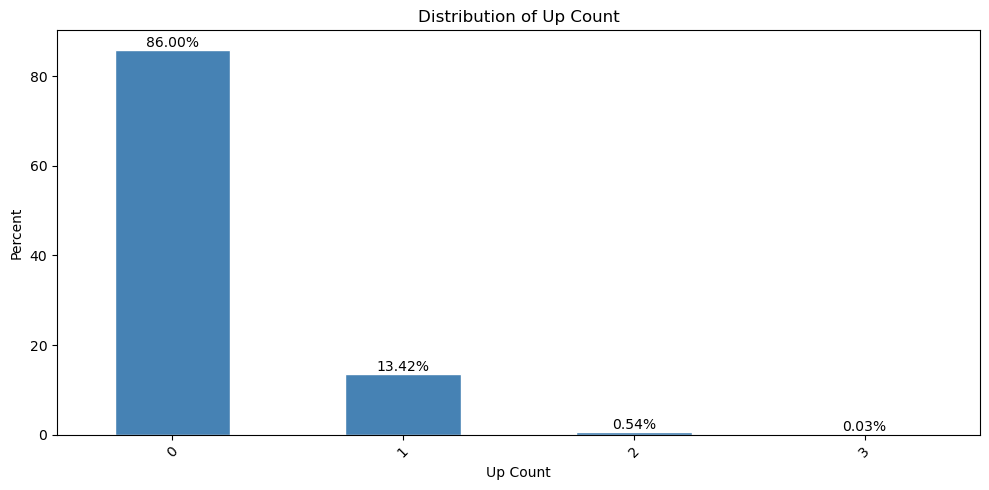

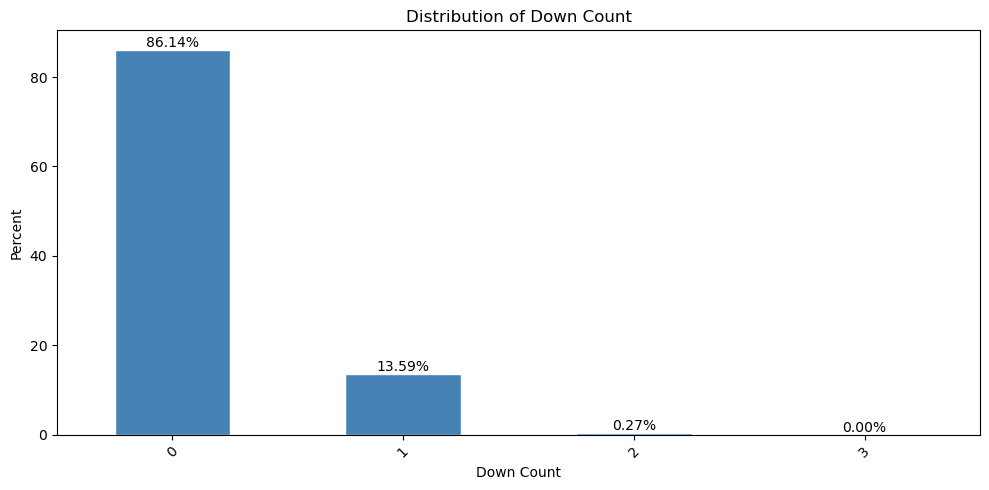

In [98]:
med_changes_cols = ["diabetesMed", "steady_count", "up_count", "down_count"]


for i, col in enumerate(med_changes_cols): 
    med_pct = (
        clean_df[col]
        .value_counts(normalize=True, sort=False)
        .mul(100)
    )

    plt.figure(figsize=(10, 5))
    ax = med_pct.plot(
        kind="bar",
        color="steelblue",
        edgecolor="white"
    )

    clean_name = col.replace("_", " ").title()

    plt.xlabel(clean_name)
    plt.ylabel("Percent")
    plt.title(f"Distribution of {clean_name}")
    plt.xticks(rotation=45)

    for i, pct in enumerate(med_pct.values):
        ax.text(
            i,
            pct,
            f"{pct:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

In [99]:
drop_meds = med_cols[~med_cols.isin(keep_meds)]

clean_df = clean_df.drop(columns = drop_meds)

In [ ]:
def categorize_icd9(code):
    """
    Convert ICD-9 diagnosis code into a broad clinical category.
    Handles numeric ICD-9 codes, V-codes, E-codes, missing values, and unknown labels.
    """

    if pd.isna(code) or code == "Unknown":
        return "Unknown"

    code = str(code).strip()

    if code.startswith("V"):
        return "Supplementary"
    if code.startswith("E"):
        return "External Injury"

    try:
        numeric_code = float(code)
    except ValueError:
        return "Other"

    if 1 <= numeric_code <= 139:
        return "Infectious"
    elif 140 <= numeric_code <= 239:
        return "Neoplasms"
    elif 240 <= numeric_code <= 279:
        if 250 <= numeric_code < 251:
            return "Diabetes"
        return "Endocrine"
    elif 280 <= numeric_code <= 289:
        return "Blood"
    elif 290 <= numeric_code <= 319:
        return "Mental"
    elif 320 <= numeric_code <= 389:
        return "Nervous"
    elif 390 <= numeric_code <= 398:
        return "Rheumatic Heart Disease"
    elif 401 <= numeric_code <= 405:
        return "Hypertension"
    elif 410 <= numeric_code <= 414:
        return "Ischemic Heart Disease"
    elif 415 <= numeric_code <= 417:
        return "Pulmonary Circulation"
    elif 420 <= numeric_code <= 429:
        return "Other Heart Disease"
    elif 430 <= numeric_code <= 438:
        return "Cerebrovascular Disease"
    elif 440 <= numeric_code <= 449:
        return "Arterial Disease"
    elif 451 <= numeric_code <= 459:
        return "Venous/Lymphatic Disease"
    elif 390 <= numeric_code <= 459:
        return "Other Circulatory"
    elif 460 <= numeric_code <= 519:
        return "Respiratory"
    elif 520 <= numeric_code <= 579:
        return "Digestive"
    elif 580 <= numeric_code <= 629:
        return "Genitourinary"
    elif 630 <= numeric_code <= 679:
        return "Pregnancy"
    elif 680 <= numeric_code <= 709:
        return "Skin"
    elif 710 <= numeric_code <= 739:
        return "Musculoskeletal"
    elif 740 <= numeric_code <= 759:
        return "Congenital"
    elif 760 <= numeric_code <= 779:
        return "Perinatal"
    elif 780 <= numeric_code <= 799:
        return "Symptoms"
    elif 800 <= numeric_code <= 999:
        return "Injury"
    else:
        return "Other"

In [132]:
diagnosis_cols = ["diag_1", "diag_2", "diag_3"]

for col in diagnosis_cols:
    clean_df[f"{col}_category"] = clean_df[col].apply(categorize_icd9)

In [133]:
for col in ["diag_1_category", "diag_2_category", "diag_3_category"]:
    print(f"\n{col}")
    print(clean_df[col].value_counts(dropna=False))


diag_1_category
diag_1_category
Ischemic Heart Disease      10567
Respiratory                 10407
Other Heart Disease         10401
Digestive                    9208
Diabetes                     8757
Symptoms                     7636
Injury                       6974
Genitourinary                5078
Musculoskeletal              4957
Cerebrovascular Disease      4479
Neoplasms                    3433
Infectious                   2768
Endocrine                    2702
Skin                         2530
Mental                       2262
Supplementary                1644
Hypertension                 1573
Arterial Disease             1364
Venous/Lymphatic Disease     1253
Nervous                      1211
Blood                        1103
Pregnancy                     687
Pulmonary Circulation         519
Rheumatic Heart Disease       180
Congenital                     51
Unknown                        21
External Injury                 1
Name: count, dtype: int64

diag_2_category
diag_2

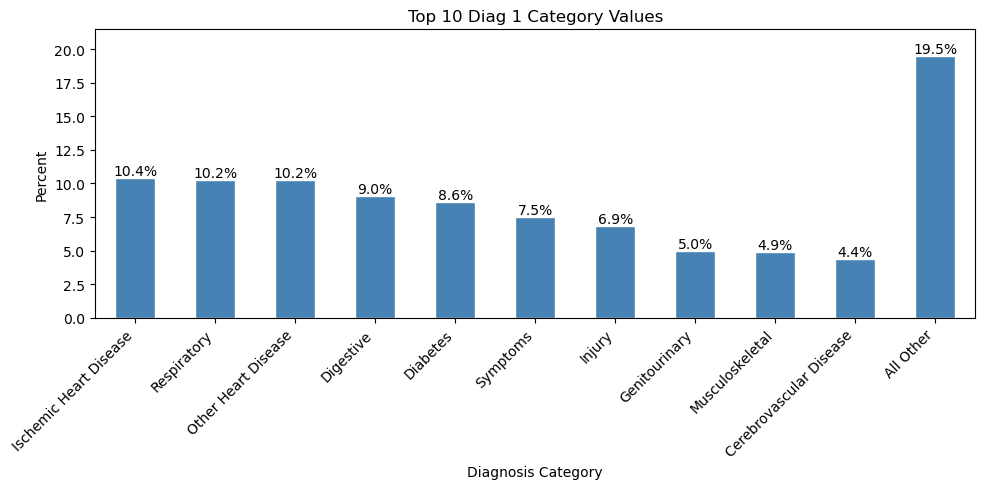

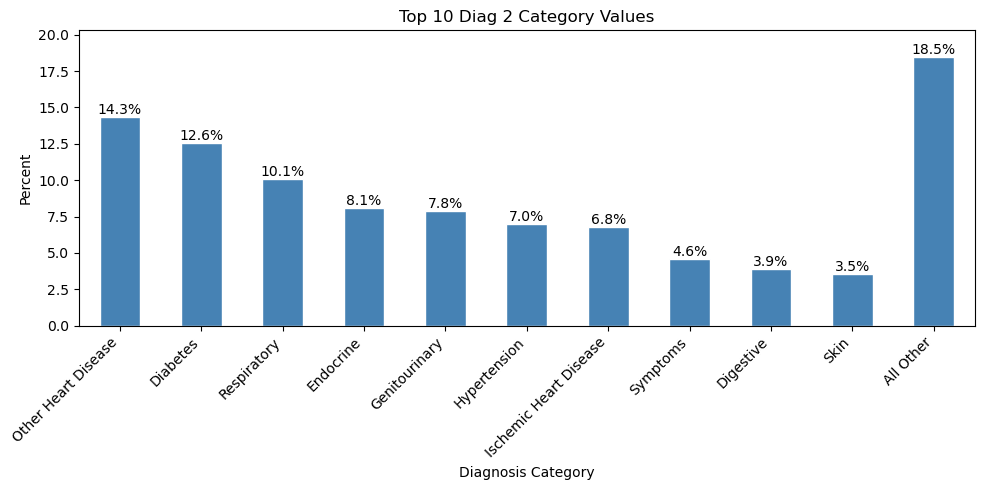

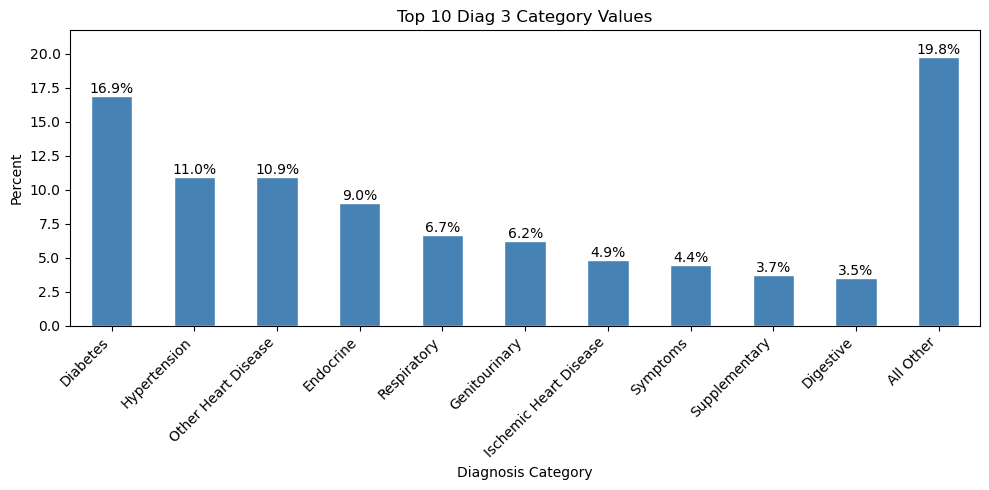

In [136]:
diagnosis_category_cols = [
    "diag_1_category",
    "diag_2_category",
    "diag_3_category"
]

for col in diagnosis_category_cols:
    category_pct = clean_df[col].value_counts(normalize=True).mul(100)

    top_10_pct = category_pct.head(10)
    all_other_pct = category_pct.iloc[11:].sum()

    plot_pct = top_10_pct.copy()
    plot_pct["All Other"] = all_other_pct

    clean_name = col.replace("_", " ").title()

    plt.figure(figsize=(10, 5))

    ax = plot_pct.plot(
        kind="bar",
        color="steelblue",
        edgecolor="white"
    )

    plt.xlabel("Diagnosis Category")
    plt.ylabel("Percent")
    plt.title(f"Top 10 {clean_name} Values")
    plt.xticks(rotation=45, ha="right")

    for i, pct in enumerate(plot_pct.values):
        ax.text(
            i,
            pct,
            f"{pct:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.ylim(0, plot_pct.max() * 1.1)
    plt.tight_layout()
    plt.show()

In [137]:
def classify_diabetes_type(code):
    if pd.isna(code):
        return "Unknown"

    code = str(code).strip()

    if not code.startswith("250"):
        return "Unknown"

    code_digits = code.replace(".", "")
    code_digits = code_digits.ljust(5, "0")

    last_digit = code_digits[-1]

    if last_digit in ["0", "2"]:
        return "Type 2 or Unspecified"
    elif last_digit in ["1", "3"]:
        return "Type 1"
    else:
        return "Diabetes - Unknown Type"


def classify_diabetes_control(code):
    if pd.isna(code):
        return "Unknown"

    code = str(code).strip()

    if not code.startswith("250"):
        return "Unknown"

    code_digits = code.replace(".", "")
    code_digits = code_digits.ljust(5, "0")

    last_digit = code_digits[-1]

    if last_digit in ["0", "1"]:
        return "Not stated as uncontrolled"
    elif last_digit in ["2", "3"]:
        return "Uncontrolled"
    else:
        return "Diabetes - Unknown Control"

In [ ]:
def find_diabetes_code(row):
    for col in diagnosis_cols:
        code = row[col]

        if pd.notna(code) and str(code).strip().startswith("250"):
            return code

    return np.nan

In [141]:
clean_df["diabetes_diag_code"] = clean_df.apply(find_diabetes_code, axis=1)

In [142]:
clean_df["diabetes_type"] = clean_df["diabetes_diag_code"].apply(
    lambda code: classify_diabetes_type(code) if pd.notna(code) else "Unknown"
)

clean_df["diabetes_control"] = clean_df["diabetes_diag_code"].apply(
    lambda code: classify_diabetes_control(code) if pd.notna(code) else "Unknown"
)

In [150]:
clean_df[[
    "diag_1", 
    "diag_1_category",
    "diag_2", 
    "diag_2_category",
    "diag_3", 
    "diag_3_category",
    "diabetes_diag_code", 
    "diabetes_type", 
    "diabetes_control"
]].head(20)

,diag_1,diag_1_category,diag_2,diag_2_category,diag_3,diag_3_category,diabetes_diag_code,diabetes_type,diabetes_control
0,250.83,Diabetes,Unknown,Unknown,Unknown,Unknown,250.83,Type 1,Uncontrolled
1,276,Endocrine,250.01,Diabetes,255,Endocrine,250.01,Type 1,Not stated as uncontrolled
2,648,Pregnancy,250,Diabetes,V27,Supplementary,250,Type 2 or Unspecified,Not stated as uncontrolled
3,8,Infectious,250.43,Diabetes,403,Hypertension,250.43,Type 1,Uncontrolled
4,197,Neoplasms,157,Neoplasms,250,Diabetes,250,Type 2 or Unspecified,Not stated as uncontrolled
5,414,Ischemic Heart Disease,411,Ischemic Heart Disease,250,Diabetes,250,Type 2 or Unspecified,Not stated as uncontrolled
6,414,Ischemic Heart Disease,411,Ischemic Heart Disease,V45,Supplementary,NaN,Unknown,Unknown
7,428,Other Heart Disease,492,Respiratory,250,Diabetes,250,Type 2 or Unspecified,Not stated as uncontrolled
8,398,Rheumatic Heart Disease,427,Other Heart Disease,38,Infectious,NaN,Unknown,Unknown
9,434,Cerebrovascular Disease,198,Neoplasms,486,Respiratory,NaN,Unknown,Unknown


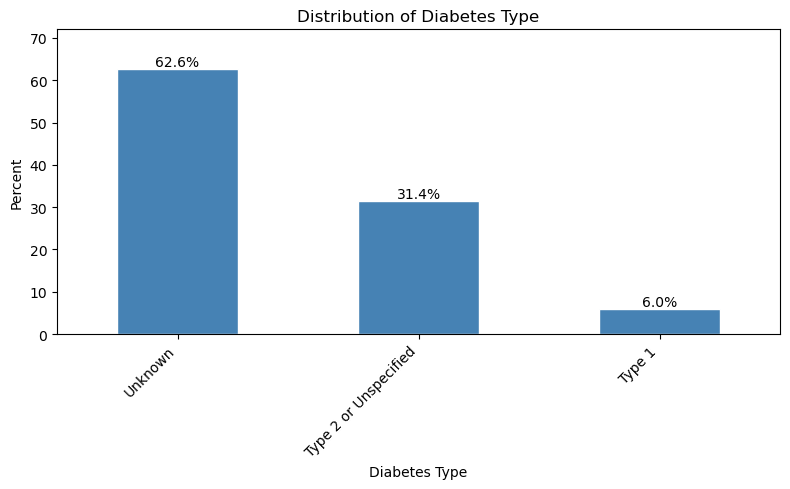

In [148]:
diabetes_type_pct = (
    clean_df["diabetes_type"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
)

plt.figure(figsize=(8, 5))

ax = diabetes_type_pct.plot(
    kind="bar",
    color="steelblue",
    edgecolor="white"
)

plt.xlabel("Diabetes Type")
plt.ylabel("Percent")
plt.title("Distribution of Diabetes Type")
plt.xticks(rotation=45, ha="right")

for i, pct in enumerate(diabetes_type_pct.values):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, diabetes_type_pct.max() * 1.15)
plt.tight_layout()
plt.show()

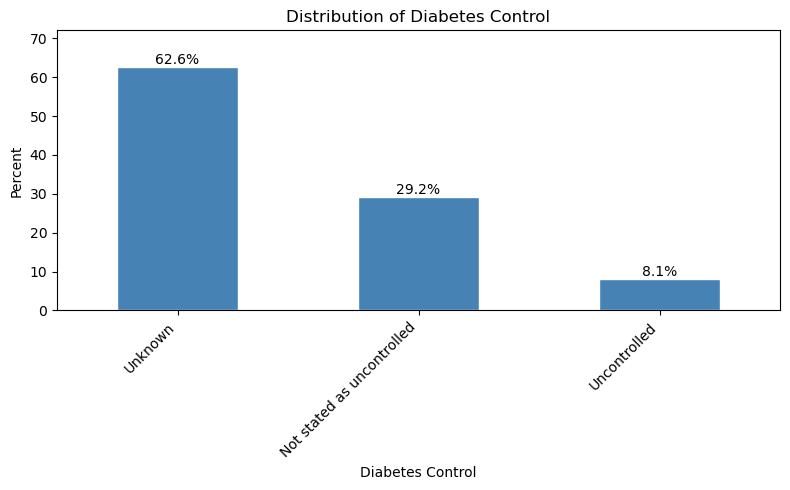

In [149]:
diabetes_control_pct = (
    clean_df["diabetes_control"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
)

plt.figure(figsize=(8, 5))

ax = diabetes_control_pct.plot(
    kind="bar",
    color="steelblue",
    edgecolor="white"
)

plt.xlabel("Diabetes Control")
plt.ylabel("Percent")
plt.title("Distribution of Diabetes Control")
plt.xticks(rotation=45, ha="right")

for i, pct in enumerate(diabetes_control_pct.values):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, diabetes_control_pct.max() * 1.15)
plt.tight_layout()
plt.show()

## Bivariate Analysis

Explores relationships between predictor variables and 30-day readmission status using correlation analysis, pairplots, and grouped comparisons.

In [100]:
analysis_df = clean_df.copy()

readmitted_mapping = {
    "NO": 0,
    "YES": 1
}

analysis_df["readmitted_30_encoded"] = analysis_df["readmitted_30"].map(readmitted_mapping)

categorical_columns = ["race", "gender", "change", "diabetesMed"]

encoded_df = pd.get_dummies(
    analysis_df[categorical_columns],
    drop_first=True,
    dtype=int
)

numeric_df = analysis_df.select_dtypes(include="number")

correlation_df = pd.concat([numeric_df, encoded_df], axis=1)

correlation_matrix = correlation_df.corr()

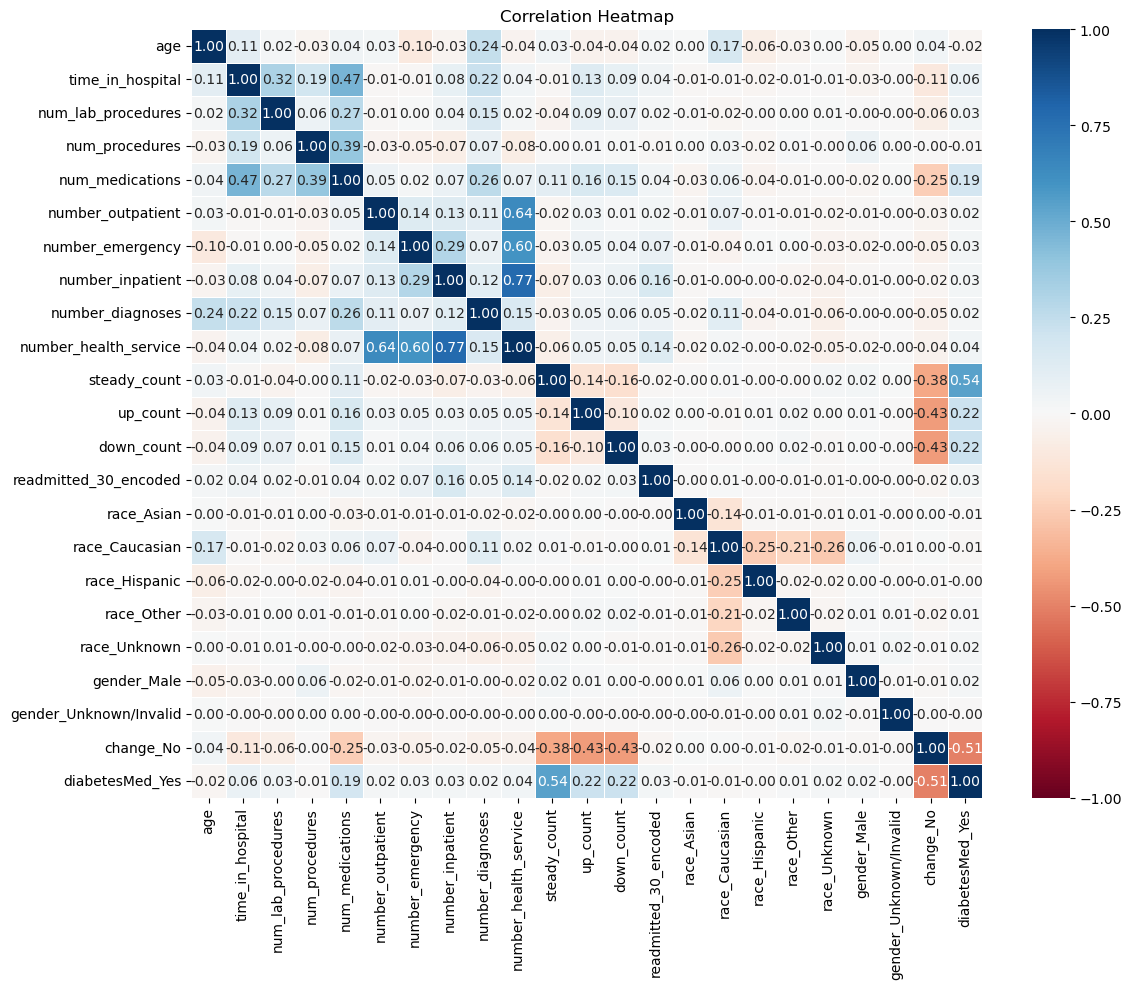

In [101]:

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdBu",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

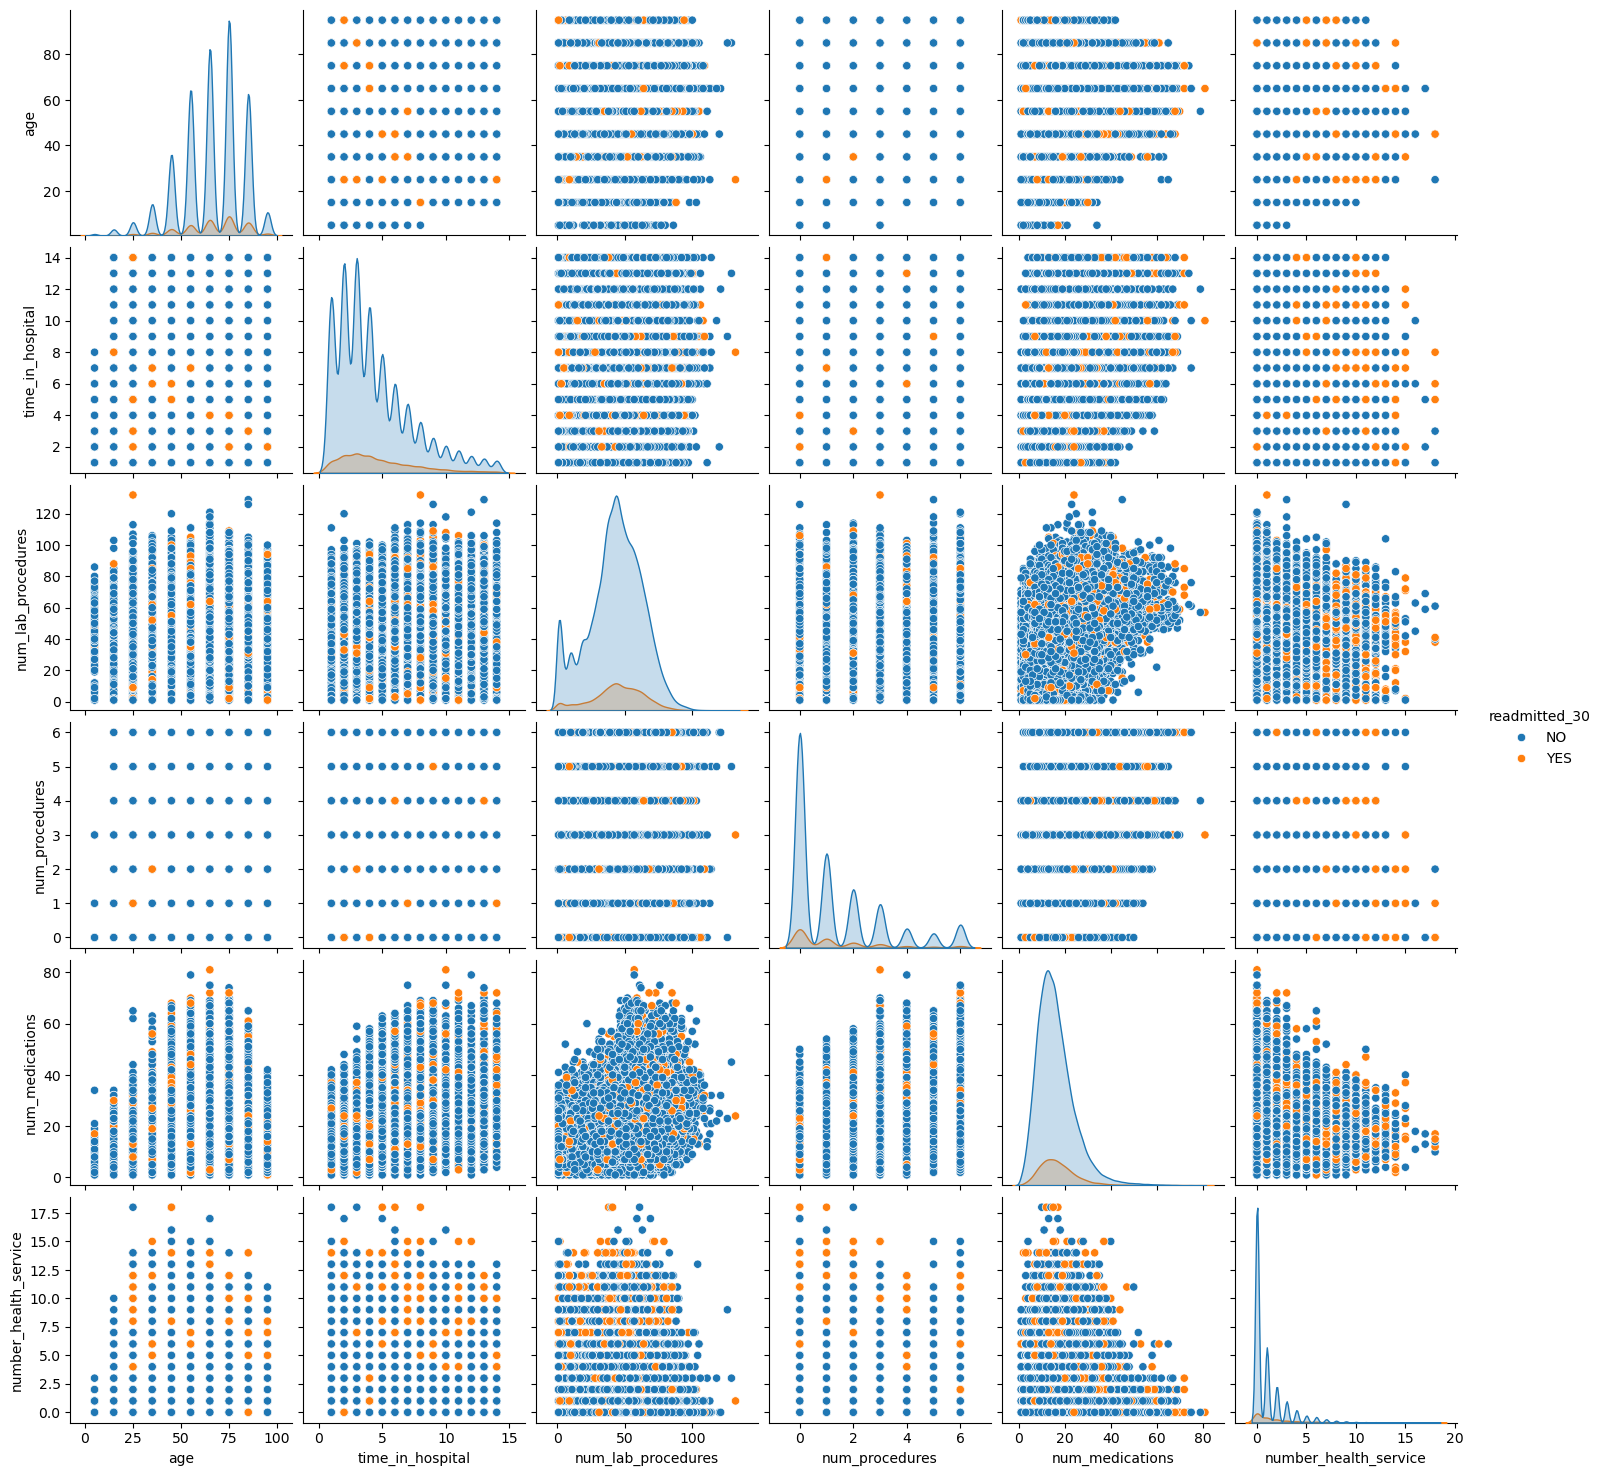

In [102]:
# More cols, more time. 6 cols take 1.75 mins. 7 cols take 2 mins. 8 cols take 3 mins
cols = [
    "age",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_health_service",
    "readmitted_30"
]

sns.pairplot(
    clean_df[cols],
    hue="readmitted_30"
)

plt.show()

### Key EDA Takeaways